# SDG 8: Credit Card Fraud Detection with Neural Networks and MLSecOps

This notebook implements a final project workflow for credit card fraud detection using neural-network-related techniques and MLSecOps evidence.

**Final project scope**

- SDG alignment: SDG 8, Decent Work and Economic Growth, through safer digital payments.
- Primary technique: tabular neural network fraud classification.
- Comparison methods: selected classical ML and anomaly detection models.
- Evidence: data quality checks, model metrics, explainability artifacts, slice checks, security stress tests, model metadata, and artifact manifest.

All final metrics and figures must come from this executed notebook.


---

## 1. Dataset and Environment Setup

The dataset file must be named `creditcard.csv` and must be in the same folder as this notebook.


In [22]:
import os
os.environ["PYTHONHASHSEED"] = "42"

import json
import math
import random
import time
import hashlib
import platform
import shutil
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, Markdown, display

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

try:
    import xgboost
    from xgboost import XGBClassifier
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost
    from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "creditcard.csv"
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
FIGURE_DIR = ARTIFACT_DIR / "figures"
MODEL_DIR = ARTIFACT_DIR / "models"
if ARTIFACT_DIR.exists():
    shutil.rmtree(ARTIFACT_DIR)
for directory in [ARTIFACT_DIR, FIGURE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_MLP_EPOCHS = 30
MLP_PATIENCE = 6
MAX_AUTOENCODER_EPOCHS = 15

TEXT_ARTIFACT_SUFFIXES = {".csv", ".json", ".md", ".txt"}

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

def sha256_artifact(path: Path) -> str:
    raw = path.read_bytes()
    if path.suffix.lower() in TEXT_ARTIFACT_SUFFIXES:
        raw = raw.replace(b"\r\n", b"\n")
    return hashlib.sha256(raw).hexdigest()

def to_builtin(obj):
    if isinstance(obj, dict):
        return {str(k): to_builtin(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_builtin(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, Path):
        return str(obj)
    return obj

def save_and_show(fig, path: Path, dpi: int = 160):
    fig.savefig(path, dpi=dpi)
    plt.close(fig)
    display(Image(filename=str(path)))

print(f"Project directory: {PROJECT_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"XGBoost: {xgboost.__version__}")
print(f"Device: {DEVICE}")


Project directory: /content
Data path: /content/creditcard.csv
Artifact directory: /content/artifacts
Python: 3.12.13
PyTorch: 2.11.0+cu128
XGBoost: 3.2.0
Device: cuda


### 1.1 Data Loading

The file is loaded from the notebook folder only. Basic schema validation is included to prevent accidental use of the wrong CSV file.


In [23]:
EXPECTED_DATASET_SHA256 = "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89"
EXPECTED_COLUMNS = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]

if not DATA_PATH.exists():
    raise FileNotFoundError(f"creditcard.csv not found at {DATA_PATH}")

dataset_sha256 = sha256_file(DATA_PATH)
if dataset_sha256.lower() != EXPECTED_DATASET_SHA256:
    raise ValueError(
        "creditcard.csv SHA-256 does not match the expected project dataset. "
        f"Expected {EXPECTED_DATASET_SHA256}, got {dataset_sha256}."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

missing_columns = [col for col in EXPECTED_COLUMNS if col not in df.columns]
extra_columns = [col for col in df.columns if col not in EXPECTED_COLUMNS]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")
if extra_columns:
    raise ValueError(f"Unexpected extra columns: {extra_columns}")

df = df[EXPECTED_COLUMNS].copy()
for col in EXPECTED_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors="raise")

if not set(df["Class"].dropna().unique()).issubset({0, 1}):
    raise ValueError("Class column must contain only 0 and 1.")

display(df.head())
print("Shape:", df.shape)
print("SHA-256:", dataset_sha256)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Shape: (284807, 31)
SHA-256: 76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89


### 1.2 Data Exploration


=== Data Types ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== DataFrame Shape ===
(284807, 31)

=== Missing Values ===
No missing values found.

=== Target Variable Distribution ===
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727% (492 out of 284807)


/tmp/ipykernel_3220/3425501765.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class", data=df, ax=axes[0], palette="coolwarm")


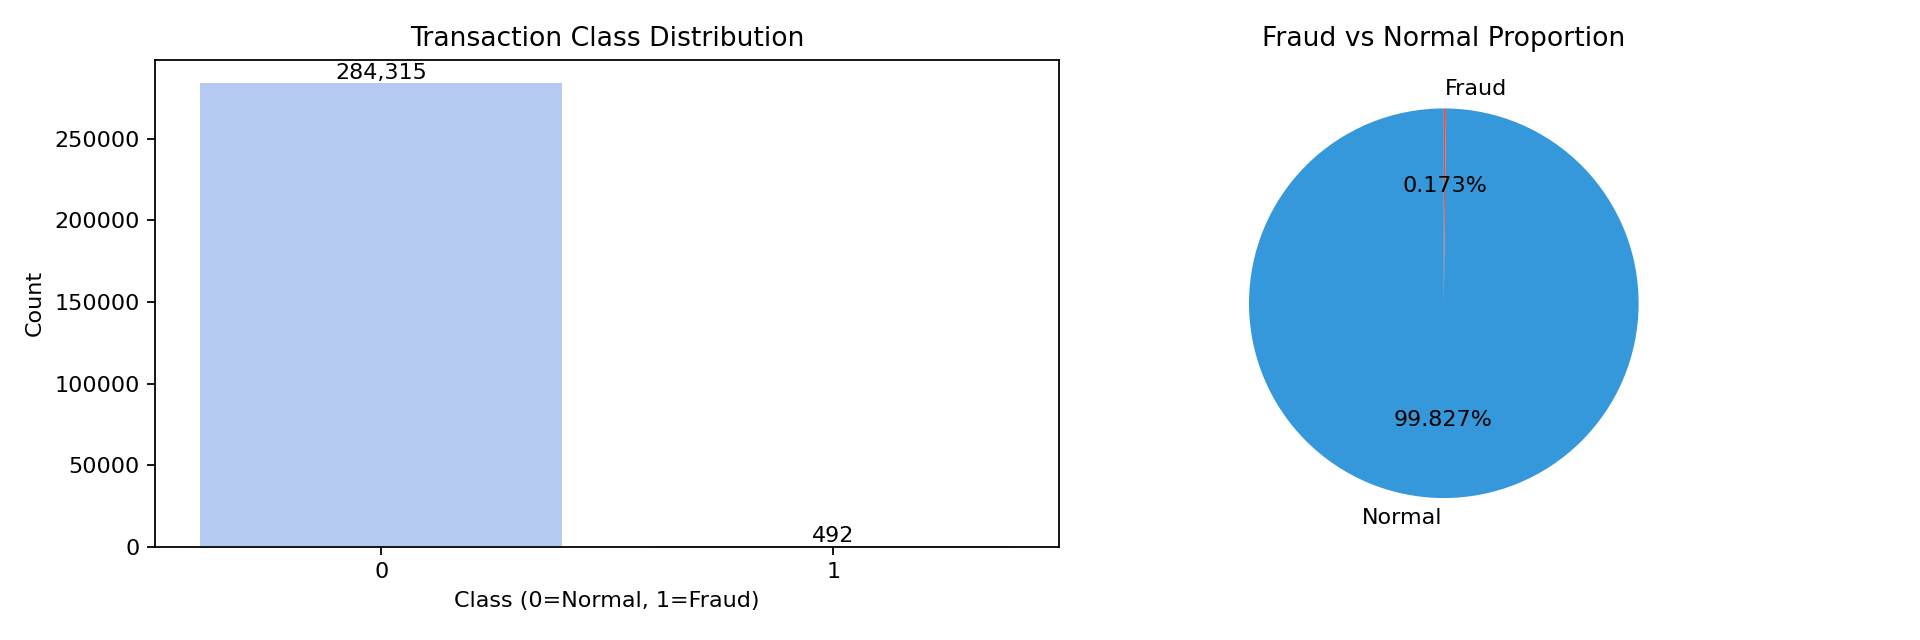


=== Numerical Feature Statistics ===


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [24]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== DataFrame Shape ===")
print(df.shape)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n=== Target Variable Distribution ===")
class_counts = df["Class"].value_counts().sort_index()
class_pct = df["Class"].value_counts(normalize=True).sort_index() * 100
print(class_counts)
print(f"\nFraud rate: {class_pct.loc[1]:.4f}% ({class_counts.loc[1]} out of {len(df)})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="Class", data=df, ax=axes[0], palette="coolwarm")
axes[0].set_title("Transaction Class Distribution")
axes[0].set_xlabel("Class (0=Normal, 1=Fraud)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2., p.get_height()),
                     ha="center", va="bottom")

axes[1].pie(class_counts.values, labels=["Normal", "Fraud"], autopct="%1.3f%%",
            colors=["#3498db", "#e74c3c"], startangle=90)
axes[1].set_title("Fraud vs Normal Proportion")
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "class_distribution.png")

print("\n=== Numerical Feature Statistics ===")
display(df[["Time", "Amount"]].describe())


### 1.3 Exploratory Visualizations


/tmp/ipykernel_3220/2837094647.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1, 0], palette="coolwarm", showfliers=False)


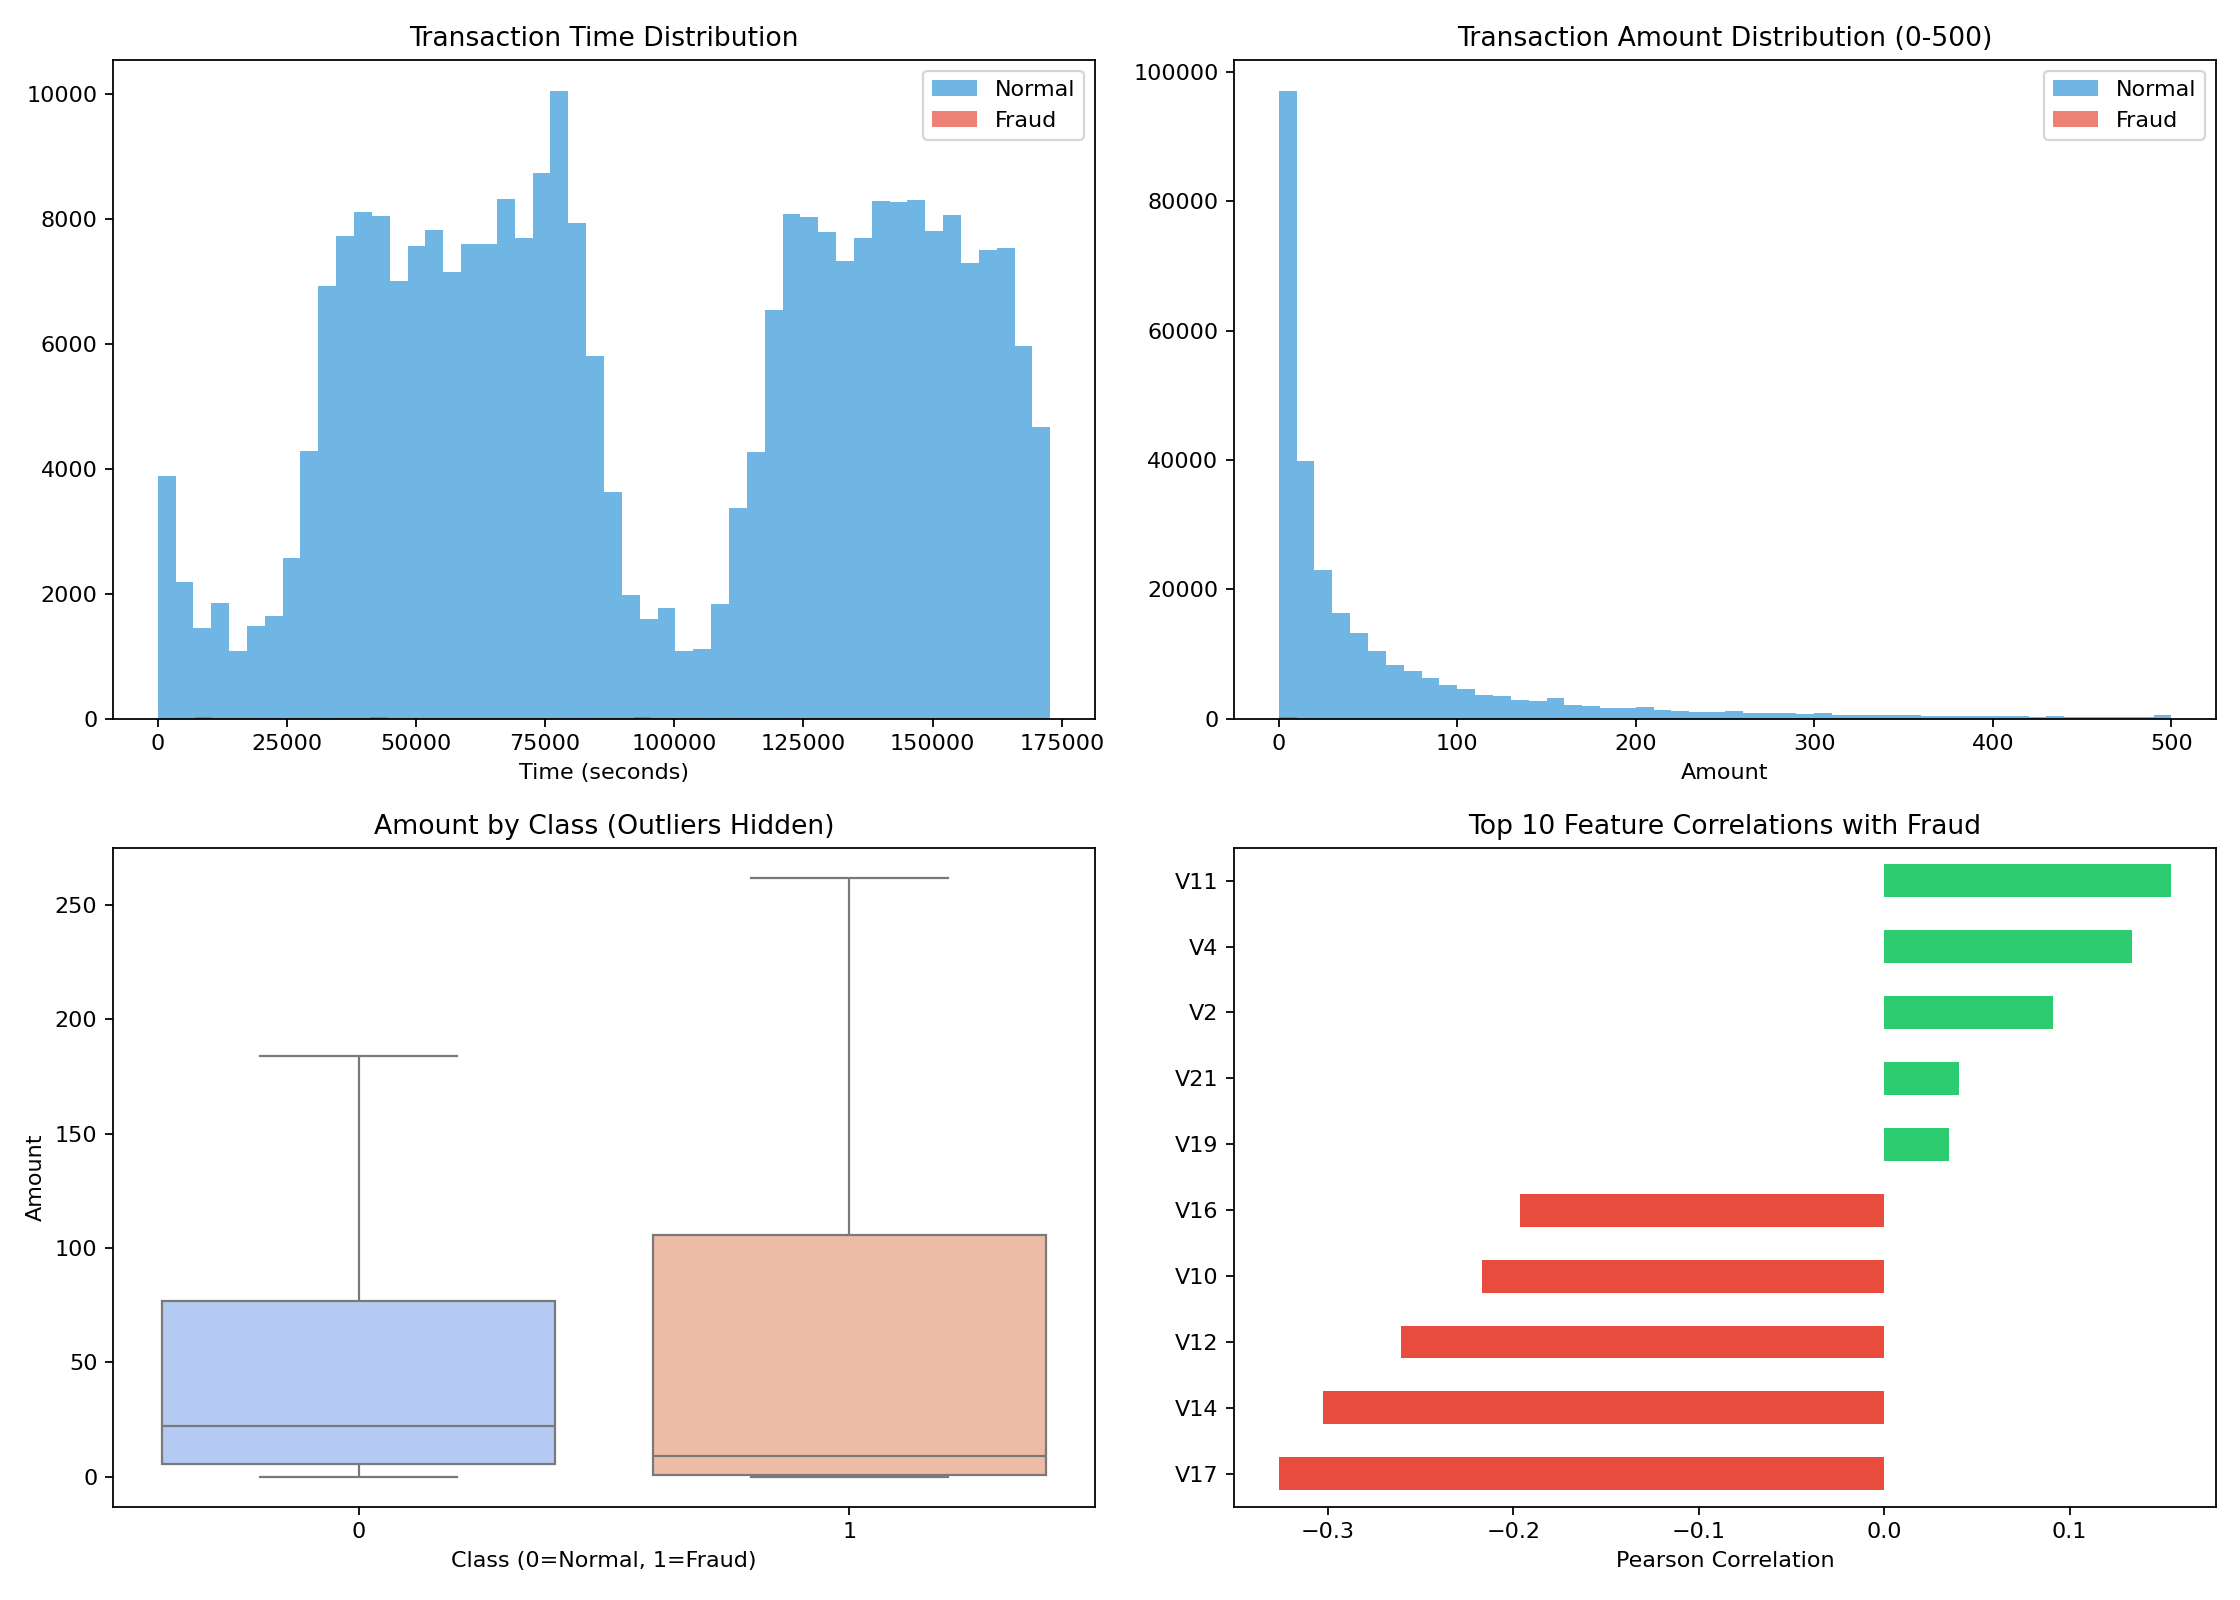

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df[df["Class"] == 0]["Time"], bins=50, alpha=0.7, label="Normal", color="#3498db")
axes[0, 0].hist(df[df["Class"] == 1]["Time"], bins=50, alpha=0.7, label="Fraud", color="#e74c3c")
axes[0, 0].set_title("Transaction Time Distribution")
axes[0, 0].set_xlabel("Time (seconds)")
axes[0, 0].legend()

axes[0, 1].hist(df[df["Class"] == 0]["Amount"], bins=50, alpha=0.7, label="Normal", color="#3498db", range=(0, 500))
axes[0, 1].hist(df[df["Class"] == 1]["Amount"], bins=50, alpha=0.7, label="Fraud", color="#e74c3c", range=(0, 500))
axes[0, 1].set_title("Transaction Amount Distribution (0-500)")
axes[0, 1].set_xlabel("Amount")
axes[0, 1].legend()

sns.boxplot(x="Class", y="Amount", data=df, ax=axes[1, 0], palette="coolwarm", showfliers=False)
axes[1, 0].set_title("Amount by Class (Outliers Hidden)")
axes[1, 0].set_xlabel("Class (0=Normal, 1=Fraud)")

correlations = df.corr(numeric_only=True)["Class"].drop("Class").sort_values()
top_corr = pd.concat([correlations.head(5), correlations.tail(5)])
top_corr.plot(kind="barh", ax=axes[1, 1], color=["#e74c3c" if x < 0 else "#2ecc71" for x in top_corr.values])
axes[1, 1].set_title("Top 10 Feature Correlations with Fraud")
axes[1, 1].set_xlabel("Pearson Correlation")

plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "eda_summary.png")


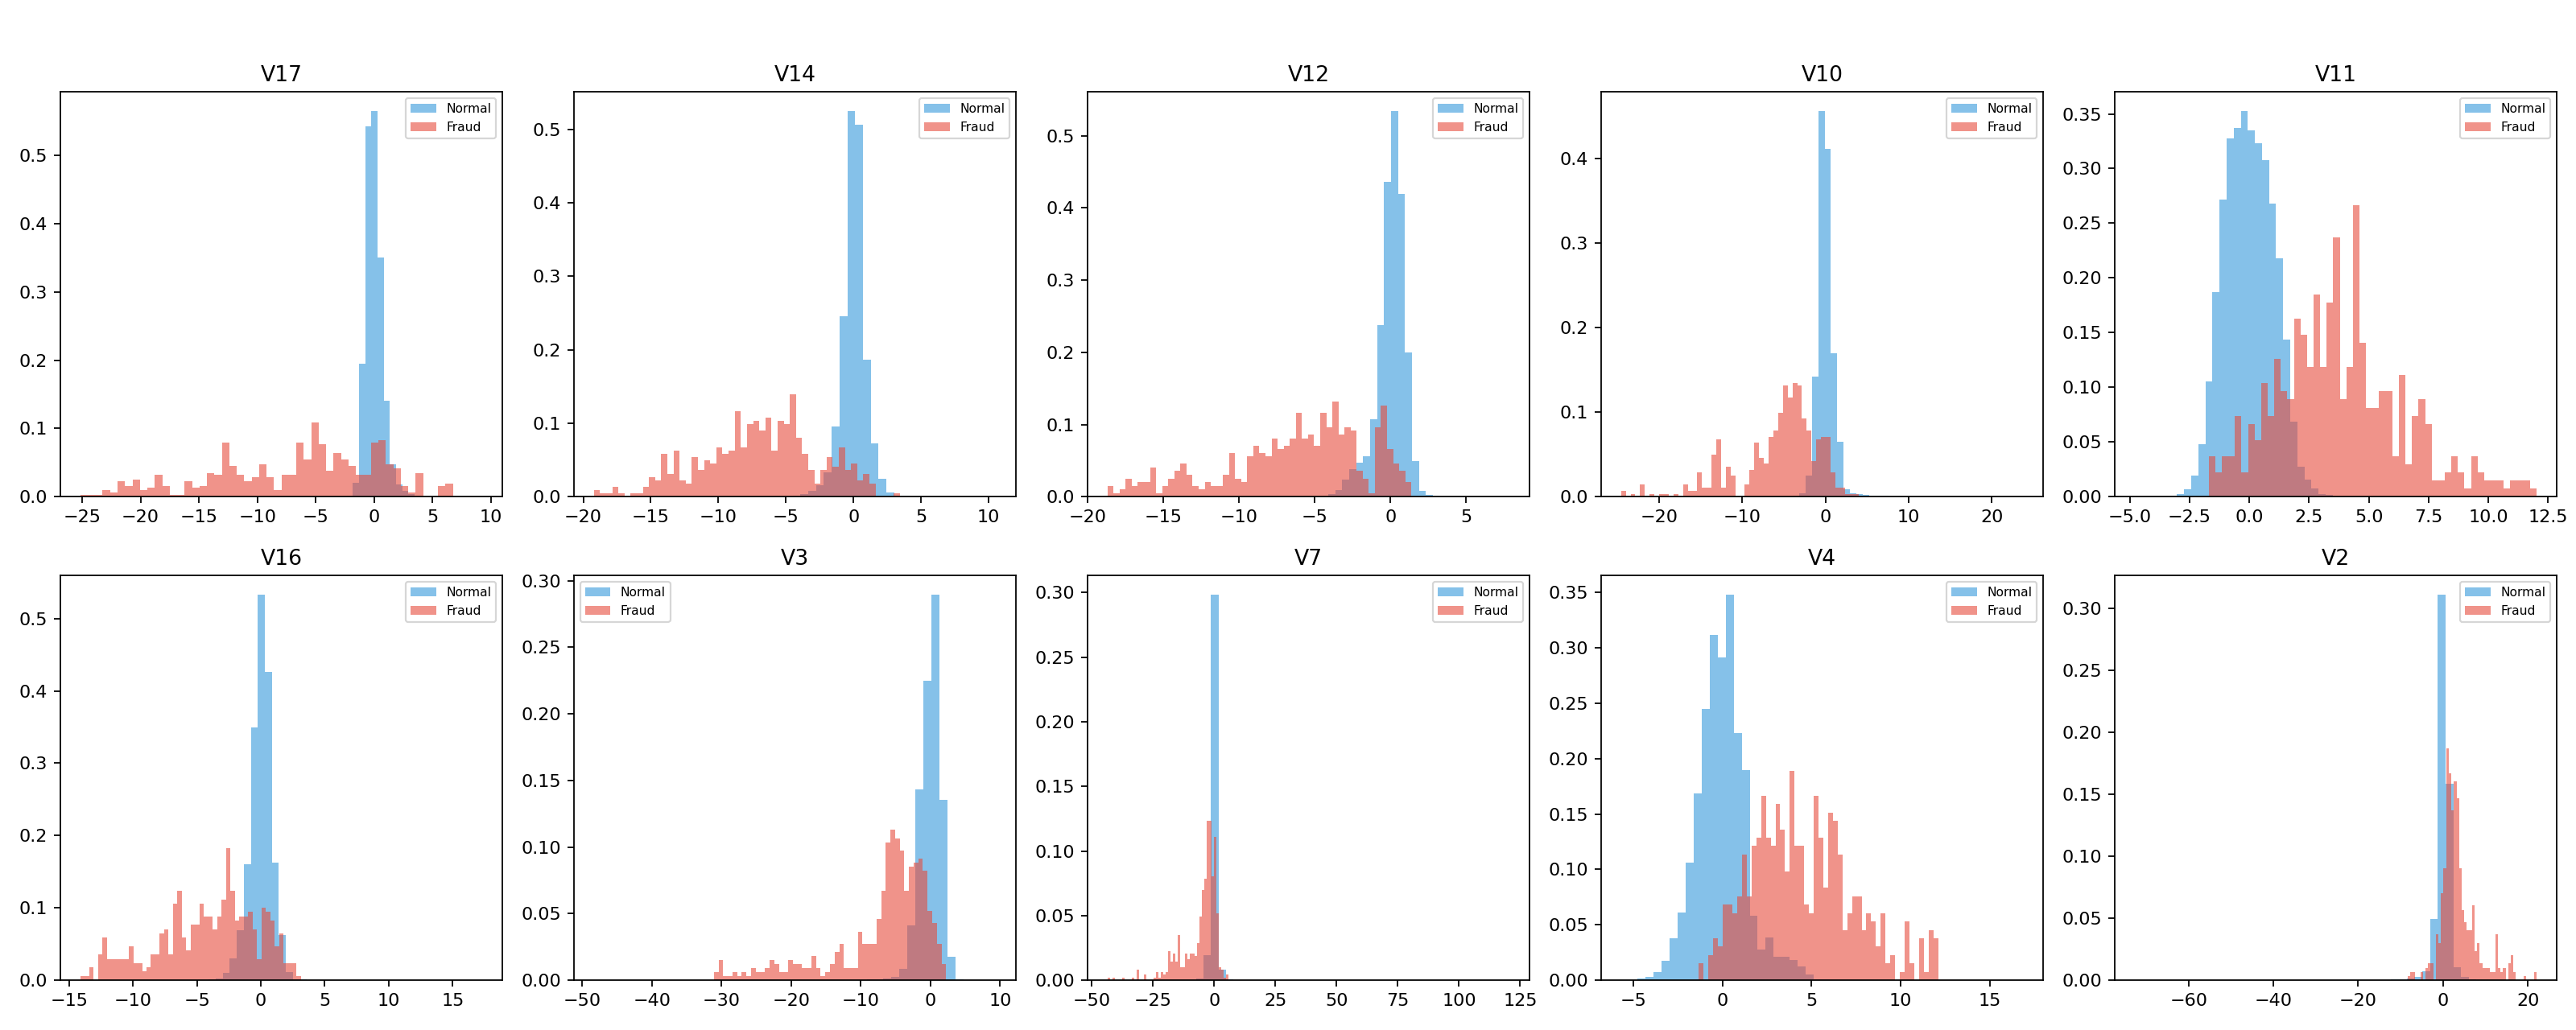

In [26]:
top_features = ["V17", "V14", "V12", "V10", "V11", "V16", "V3", "V7", "V4", "V2"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, feat in enumerate(top_features):
    ax = axes[i // 5, i % 5]
    ax.hist(df[df["Class"] == 0][feat], bins=50, alpha=0.6, label="Normal", density=True, color="#3498db")
    ax.hist(df[df["Class"] == 1][feat], bins=50, alpha=0.6, label="Fraud", density=True, color="#e74c3c")
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle("PCA Feature Distributions: Normal vs Fraud", fontsize=14, y=1.02)
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "pca_feature_distributions.png")


---

## 2. Feature Engineering, Splitting, and Class Imbalance Handling

The original workflow is extended with train-only scaling so that validation and test data do not influence preprocessing parameters.


In [27]:
raw_X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    raw_X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    hour = (out["Time"] % 86400) / 3600.0
    out["Hour"] = hour
    out["Hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    out["Hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
    out["log_Amount"] = np.log1p(out["Amount"])
    return out

train_eng = add_engineered_features(X_train_raw)
val_eng = add_engineered_features(X_val_raw)
test_eng = add_engineered_features(X_test_raw)

numeric_scaler = StandardScaler()
log_scaler = StandardScaler()
numeric_scaler.fit(train_eng[["Time", "Amount"]])
log_scaler.fit(train_eng[["log_Amount"]])

def transform_features(frame: pd.DataFrame) -> pd.DataFrame:
    eng = add_engineered_features(frame)
    scaled_numeric = numeric_scaler.transform(eng[["Time", "Amount"]])
    scaled_log_amount = log_scaler.transform(eng[["log_Amount"]])

    transformed = pd.DataFrame(index=eng.index)
    for col in [f"V{i}" for i in range(1, 29)]:
        transformed[col] = eng[col].astype(float)
    transformed["Hour"] = eng["Hour"].astype(float)
    transformed["Hour_sin"] = eng["Hour_sin"].astype(float)
    transformed["Hour_cos"] = eng["Hour_cos"].astype(float)
    transformed["scaled_Time"] = scaled_numeric[:, 0]
    transformed["scaled_Amount"] = scaled_numeric[:, 1]
    transformed["scaled_log_Amount"] = scaled_log_amount[:, 0]
    return transformed

X_train = transform_features(X_train_raw)
X_val = transform_features(X_val_raw)
X_test = transform_features(X_test_raw)
feature_columns = list(X_train.columns)

print(f"Training set:   {X_train.shape[0]:>7,} samples  |  Fraud: {y_train.sum():>3} ({y_train.mean()*100:.3f}%)")
print(f"Validation set: {X_val.shape[0]:>7,} samples  |  Fraud: {y_val.sum():>3} ({y_val.mean()*100:.3f}%)")
print(f"Test set:       {X_test.shape[0]:>7,} samples  |  Fraud: {y_test.sum():>3} ({y_test.mean()*100:.3f}%)")
print("Feature count:", len(feature_columns))
display(X_train.head())


Training set:   227,845 samples  |  Fraud: 394 (0.173%)
Validation set:  28,481 samples  |  Fraud:  49 (0.172%)
Test set:        28,481 samples  |  Fraud:  49 (0.172%)
Feature count: 34


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V25,V26,V27,V28,Hour,Hour_sin,Hour_cos,scaled_Time,scaled_Amount,scaled_log_Amount
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,...,-0.350316,-0.388907,0.077641,-0.032248,20.977500,-0.711260,0.702929,1.411588,-0.322494,-0.624639
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,...,0.512885,-0.471198,0.002520,-0.069002,10.576944,0.363996,-0.931400,0.623141,-0.339764,-1.068403
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,...,0.826684,0.913773,0.038049,0.185340,11.441944,0.145579,-0.989347,-1.130680,0.346693,1.218601
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,...,-0.278032,-0.162068,0.018045,-0.063005,12.840000,-0.218143,-0.975917,0.794699,-0.327360,-0.720392
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,...,-0.292234,-0.144622,-0.032580,-0.064194,16.488611,-0.922734,-0.385436,-0.748102,-0.008281,0.793481


In [28]:
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Normal: {(y_train == 0).sum():>6,}  |  Fraud: {(y_train == 1).sum():>6,}")
print("\nAfter SMOTE:")
print(f"  Normal: {(y_train_smote == 0).sum():>6,}  |  Fraud: {(y_train_smote == 1).sum():>6,}")

X_train_np = X_train.to_numpy(dtype=np.float32)
X_val_np = X_val.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)
y_train_np = y_train.to_numpy(dtype=np.float32)
y_val_np = y_val.to_numpy(dtype=np.float32)
y_test_np = y_test.to_numpy(dtype=np.int64)

joblib.dump(
    {"numeric_scaler": numeric_scaler, "log_scaler": log_scaler, "feature_columns": feature_columns},
    MODEL_DIR / "preprocessing.joblib"
)


Before SMOTE:
  Normal: 227,451  |  Fraud:    394

After SMOTE:
  Normal: 227,451  |  Fraud: 227,451


['/content/artifacts/models/preprocessing.joblib']

---

## 3. Model Training

The final primary model is a tabular neural network. Classical models are kept as comparison points, and the autoencoder is included as an NN-related anomaly detection extension.


In [29]:
def tune_threshold(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_values = (2 * precision * recall) / np.clip(precision + recall, 1e-12, None)
    if len(thresholds) == 0:
        return 0.5, {"validation_precision": float(precision[0]), "validation_recall": float(recall[0]), "validation_f1": float(f1_values[0])}
    best_idx = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_idx]), {
        "validation_precision": float(precision[best_idx]),
        "validation_recall": float(recall[best_idx]),
        "validation_f1": float(f1_values[best_idx]),
    }

def evaluate_scores(name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "Model": name,
        "Threshold": float(threshold),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1-Score": float(f1_score(y_true, y_pred, zero_division=0)),
        "ROC-AUC": float(roc_auc_score(y_true, y_score)),
        "PR-AUC": float(average_precision_score(y_true, y_score)),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

def print_model_report(name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    print(f"\n=== {name} ===")
    print(f"Threshold: {threshold:.6f}")
    print(classification_report(y_true, y_pred, target_names=["Normal", "Fraud"], zero_division=0))

models = {}
model_scores = {}
model_thresholds = {}
training_times = {}
results = []


In [30]:
print("Training Decision Tree...")
t0 = time.time()
dt_model = DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=SEED)
dt_model.fit(X_train_smote, y_train_smote)
val_score = dt_model.predict_proba(X_val)[:, 1]
threshold, val_info = tune_threshold(y_val.to_numpy(dtype=int), val_score)
test_score = dt_model.predict_proba(X_test)[:, 1]
result = evaluate_scores("Decision Tree", y_test_np, test_score, threshold)
result.update(val_info)
models["Decision Tree"] = dt_model
model_scores["Decision Tree"] = test_score
model_thresholds["Decision Tree"] = threshold
training_times["Decision Tree"] = time.time() - t0
results.append(result)
print_model_report("Decision Tree", y_test_np, test_score, threshold)

print("Training Random Forest...")
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight="balanced",
                                  random_state=SEED, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
val_score = rf_model.predict_proba(X_val)[:, 1]
threshold, val_info = tune_threshold(y_val.to_numpy(dtype=int), val_score)
test_score = rf_model.predict_proba(X_test)[:, 1]
result = evaluate_scores("Random Forest", y_test_np, test_score, threshold)
result.update(val_info)
models["Random Forest"] = rf_model
model_scores["Random Forest"] = test_score
model_thresholds["Random Forest"] = threshold
training_times["Random Forest"] = time.time() - t0
results.append(result)
print_model_report("Random Forest", y_test_np, test_score, threshold)

print("Training XGBoost...")
t0 = time.time()
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
val_score = xgb_model.predict_proba(X_val)[:, 1]
threshold, val_info = tune_threshold(y_val.to_numpy(dtype=int), val_score)
test_score = xgb_model.predict_proba(X_test)[:, 1]
result = evaluate_scores("XGBoost", y_test_np, test_score, threshold)
result.update(val_info)
models["XGBoost"] = xgb_model
model_scores["XGBoost"] = test_score
model_thresholds["XGBoost"] = threshold
training_times["XGBoost"] = time.time() - t0
results.append(result)
print_model_report("XGBoost", y_test_np, test_score, threshold)

print("Training Isolation Forest...")
t0 = time.time()
iso_model = IsolationForest(n_estimators=200, contamination=float(y_train.mean()),
                            random_state=SEED, n_jobs=-1)
iso_model.fit(X_train)
val_score = -iso_model.decision_function(X_val)
threshold, val_info = tune_threshold(y_val.to_numpy(dtype=int), val_score)
test_score = -iso_model.decision_function(X_test)
result = evaluate_scores("Isolation Forest", y_test_np, test_score, threshold)
result.update(val_info)
models["Isolation Forest"] = iso_model
model_scores["Isolation Forest"] = test_score
model_thresholds["Isolation Forest"] = threshold
training_times["Isolation Forest"] = time.time() - t0
results.append(result)
print_model_report("Isolation Forest", y_test_np, test_score, threshold)


Training Decision Tree...

=== Decision Tree ===
Threshold: 0.999079
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.46      0.82      0.59        49

    accuracy                           1.00     28481
   macro avg       0.73      0.91      0.79     28481
weighted avg       1.00      1.00      1.00     28481

Training Random Forest...

=== Random Forest ===
Threshold: 0.832241
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.91      0.80      0.85        49

    accuracy                           1.00     28481
   macro avg       0.95      0.90      0.92     28481
weighted avg       1.00      1.00      1.00     28481

Training XGBoost...

=== XGBoost ===
Threshold: 0.934560
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.93      0.86      0.8

In [31]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 96),
            nn.BatchNorm1d(96),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(96, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(48, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def predict_proba_torch(model, X_np, batch_size=8192):
    model.eval()
    probs = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np.astype(np.float32))),
                        batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

print("Training Primary NN - Tabular MLP...")
t0 = time.time()
class_sample_counts = np.bincount(y_train_np.astype(int), minlength=2).astype(float)
sample_weights = np.where(y_train_np == 1, 1.0 / class_sample_counts[1], 1.0 / class_sample_counts[0])
sampler = WeightedRandomSampler(torch.from_numpy(sample_weights.astype(np.float64)),
                                num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(y_train_np)),
                          batch_size=4096, sampler=sampler)

mlp_model = FraudMLP(input_dim=X_train_np.shape[1]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)

best_state = None
best_val_pr_auc = -1.0
best_epoch = -1
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_MLP_EPOCHS + 1):
    mlp_model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        optimizer.zero_grad()
        logits = mlp_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(float(loss.detach().cpu()))

    val_prob = predict_proba_torch(mlp_model, X_val_np)
    val_pr_auc = average_precision_score(y_val_np.astype(int), val_prob)
    val_roc_auc = roc_auc_score(y_val_np.astype(int), val_prob)
    mean_loss = float(np.mean(batch_losses))
    history.append({"epoch": epoch, "train_loss": mean_loss, "val_pr_auc": float(val_pr_auc), "val_roc_auc": float(val_roc_auc)})
    print(f"Epoch {epoch:02d}: loss={mean_loss:.5f}, val_pr_auc={val_pr_auc:.5f}, val_roc_auc={val_roc_auc:.5f}")

    if val_pr_auc > best_val_pr_auc + 1e-5:
        best_val_pr_auc = float(val_pr_auc)
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in mlp_model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= MLP_PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}")
            break

if best_state is not None:
    mlp_model.load_state_dict(best_state)
mlp_model.to(DEVICE)

mlp_val_prob = predict_proba_torch(mlp_model, X_val_np)
threshold, val_info = tune_threshold(y_val_np.astype(int), mlp_val_prob)
mlp_test_prob = predict_proba_torch(mlp_model, X_test_np)
result = evaluate_scores("Primary NN - Tabular MLP", y_test_np, mlp_test_prob, threshold)
result.update(val_info)
result["best_epoch"] = int(best_epoch)
result["best_validation_pr_auc"] = float(best_val_pr_auc)
models["Primary NN - Tabular MLP"] = mlp_model
model_scores["Primary NN - Tabular MLP"] = mlp_test_prob
model_thresholds["Primary NN - Tabular MLP"] = threshold
training_times["Primary NN - Tabular MLP"] = time.time() - t0
results.append(result)
pd.DataFrame(history).to_csv(ARTIFACT_DIR / "mlp_training_history.csv", index=False)
print_model_report("Primary NN - Tabular MLP", y_test_np, mlp_test_prob, threshold)


Training Primary NN - Tabular MLP...
Epoch 01: loss=0.39864, val_pr_auc=0.74684, val_roc_auc=0.97371
Epoch 02: loss=0.14361, val_pr_auc=0.77008, val_roc_auc=0.97615
Epoch 03: loss=0.09810, val_pr_auc=0.73397, val_roc_auc=0.97475
Epoch 04: loss=0.06989, val_pr_auc=0.74143, val_roc_auc=0.97544
Epoch 05: loss=0.05174, val_pr_auc=0.73950, val_roc_auc=0.97640
Epoch 06: loss=0.03994, val_pr_auc=0.69759, val_roc_auc=0.97741
Epoch 07: loss=0.03229, val_pr_auc=0.72088, val_roc_auc=0.97632
Epoch 08: loss=0.02812, val_pr_auc=0.76186, val_roc_auc=0.97754
Early stopping at epoch 8. Best epoch: 2

=== Primary NN - Tabular MLP ===
Threshold: 0.983898
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.85      0.80      0.82        49

    accuracy                           1.00     28481
   macro avg       0.92      0.90      0.91     28481
weighted avg       1.00      1.00      1.00     28481



In [32]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 48), nn.ReLU(), nn.Linear(48, 16), nn.ReLU(), nn.Linear(16, 8), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(8, 16), nn.ReLU(), nn.Linear(16, 48), nn.ReLU(), nn.Linear(48, input_dim))

    def forward(self, x):
        return self.decoder(self.encoder(x))

def reconstruction_error(model, X_np, batch_size=8192):
    model.eval()
    errors = []
    loader = DataLoader(TensorDataset(torch.from_numpy(X_np.astype(np.float32))), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            rec = model(xb)
            err = torch.mean((rec - xb) ** 2, dim=1)
            errors.append(err.cpu().numpy())
    return np.concatenate(errors)

print("Training NN Autoencoder Anomaly Detector...")
t0 = time.time()
normal_train = X_train_np[y_train_np == 0]
ae_model = Autoencoder(input_dim=X_train_np.shape[1]).to(DEVICE)
ae_optimizer = torch.optim.AdamW(ae_model.parameters(), lr=1e-3, weight_decay=1e-5)
ae_loss_fn = nn.MSELoss()
ae_loader = DataLoader(TensorDataset(torch.from_numpy(normal_train.astype(np.float32))),
                       batch_size=4096, shuffle=True)
ae_history = []
for epoch in range(1, MAX_AUTOENCODER_EPOCHS + 1):
    ae_model.train()
    losses = []
    for (xb,) in ae_loader:
        xb = xb.to(DEVICE)
        ae_optimizer.zero_grad()
        reconstruction = ae_model(xb)
        loss = ae_loss_fn(reconstruction, xb)
        loss.backward()
        ae_optimizer.step()
        losses.append(float(loss.detach().cpu()))
    mean_loss = float(np.mean(losses))
    ae_history.append({"epoch": epoch, "train_reconstruction_loss": mean_loss})
    print(f"Autoencoder epoch {epoch:02d}: reconstruction_loss={mean_loss:.6f}")

ae_val_error = reconstruction_error(ae_model, X_val_np)
threshold, val_info = tune_threshold(y_val_np.astype(int), ae_val_error)
ae_test_error = reconstruction_error(ae_model, X_test_np)
result = evaluate_scores("NN Autoencoder Anomaly Detector", y_test_np, ae_test_error, threshold)
result.update(val_info)
models["NN Autoencoder Anomaly Detector"] = ae_model
model_scores["NN Autoencoder Anomaly Detector"] = ae_test_error
model_thresholds["NN Autoencoder Anomaly Detector"] = threshold
training_times["NN Autoencoder Anomaly Detector"] = time.time() - t0
results.append(result)
pd.DataFrame(ae_history).to_csv(ARTIFACT_DIR / "autoencoder_training_history.csv", index=False)
print_model_report("NN Autoencoder Anomaly Detector", y_test_np, ae_test_error, threshold)


Training NN Autoencoder Anomaly Detector...
Autoencoder epoch 01: reconstruction_loss=6.592750
Autoencoder epoch 02: reconstruction_loss=1.087659
Autoencoder epoch 03: reconstruction_loss=0.922992
Autoencoder epoch 04: reconstruction_loss=0.790293
Autoencoder epoch 05: reconstruction_loss=0.701415
Autoencoder epoch 06: reconstruction_loss=0.620227
Autoencoder epoch 07: reconstruction_loss=0.564895
Autoencoder epoch 08: reconstruction_loss=0.514982
Autoencoder epoch 09: reconstruction_loss=0.464165
Autoencoder epoch 10: reconstruction_loss=0.425758
Autoencoder epoch 11: reconstruction_loss=0.398532
Autoencoder epoch 12: reconstruction_loss=0.378690
Autoencoder epoch 13: reconstruction_loss=0.362386
Autoencoder epoch 14: reconstruction_loss=0.348432
Autoencoder epoch 15: reconstruction_loss=0.336254

=== NN Autoencoder Anomaly Detector ===
Threshold: 12.052119
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0

---

## 4. Model Evaluation and Visualization


In [33]:
results_df = pd.DataFrame(results)
results_df["Training Seconds"] = results_df["Model"].map(training_times)
display_cols = ["Model", "Threshold", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC", "TN", "FP", "FN", "TP", "Training Seconds"]
results_df = results_df[display_cols + [c for c in results_df.columns if c not in display_cols]]
results_df.to_csv(ARTIFACT_DIR / "metrics_summary.csv", index=False)

print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
display(results_df.style.highlight_max(subset=["Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC"], color="lightgreen"))

primary_metrics = to_builtin(results_df[results_df["Model"] == "Primary NN - Tabular MLP"].iloc[0].to_dict())
(ARTIFACT_DIR / "primary_model_metrics.json").write_text(json.dumps(primary_metrics, indent=2), encoding="utf-8")


MODEL COMPARISON SUMMARY


,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,TN,FP,FN,TP,Training Seconds,validation_precision,validation_recall,validation_f1,best_epoch,best_validation_pr_auc
0,Decision Tree,0.999079,0.998034,0.459770,0.816327,0.588235,0.883264,0.382336,28385,47,9,40,33.848050,0.455696,0.734694,0.562500,nan,nan
1,Random Forest,0.832241,0.999508,0.906977,0.795918,0.847826,0.975146,0.865355,28428,4,10,39,331.297019,0.900000,0.734694,0.808989,nan,nan
2,XGBoost,0.934560,0.999649,0.933333,0.857143,0.893617,0.979397,0.903388,28429,3,7,42,11.038058,0.951220,0.795918,0.866667,nan,nan
3,Isolation Forest,-0.001962,0.997402,0.272727,0.306122,0.288462,0.952894,0.164332,28392,40,34,15,4.869132,0.258621,0.306122,0.280374,nan,nan
4,Primary NN - Tabular MLP,0.983898,0.999403,0.847826,0.795918,0.821053,0.980021,0.826704,28425,7,10,39,20.880039,0.829787,0.795918,0.812500,2.000000,0.770078
5,NN Autoencoder Anomaly Detector,12.052119,0.998315,0.515152,0.346939,0.414634,0.961497,0.496681,28416,16,32,17,18.515178,0.617647,0.428571,0.506024,nan,nan


551

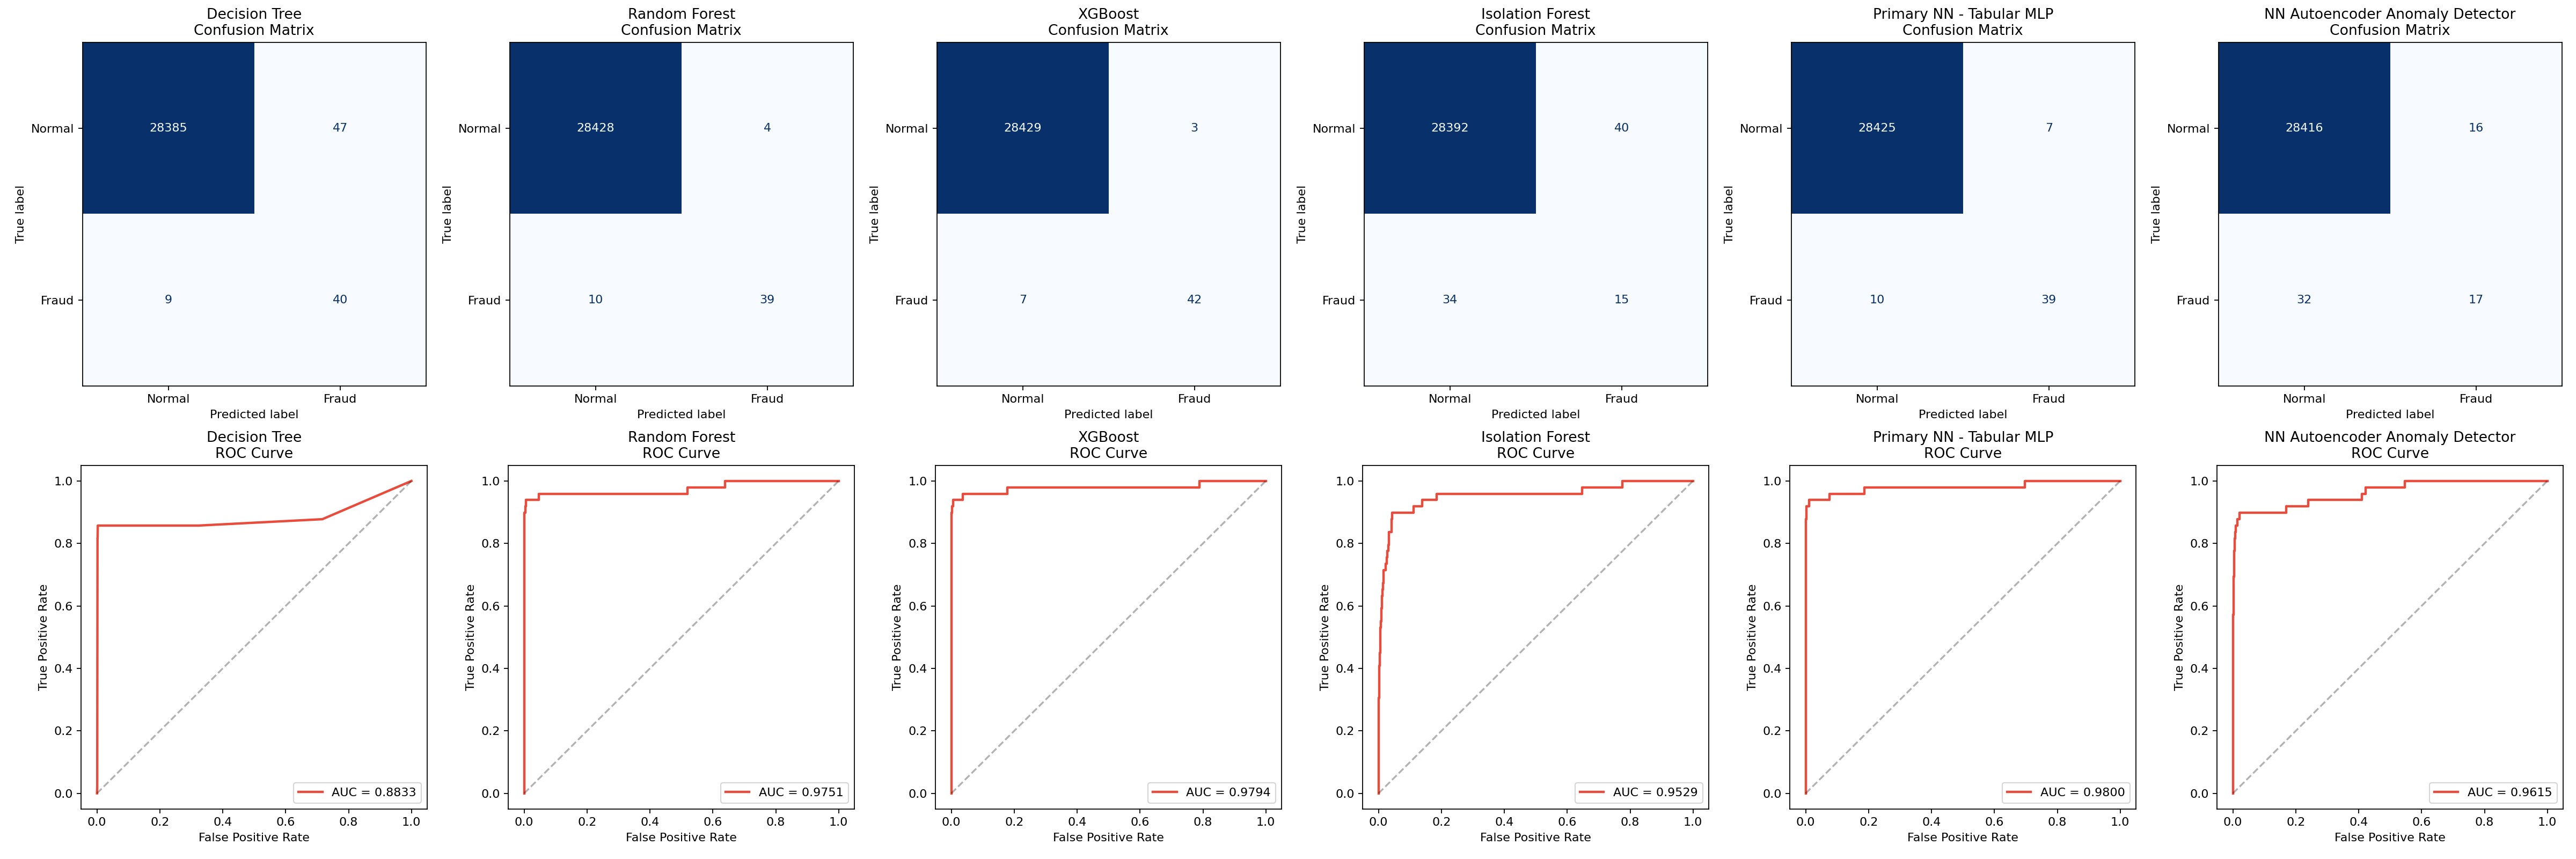

In [34]:
fig, axes = plt.subplots(2, len(model_scores), figsize=(5 * len(model_scores), 10))
if len(model_scores) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

for i, (name, score) in enumerate(model_scores.items()):
    threshold = model_thresholds[name]
    y_pred = (score >= threshold).astype(int)

    cm = confusion_matrix(y_test_np, y_pred, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(ax=axes[0, i], cmap="Blues", colorbar=False)
    axes[0, i].set_title(f"{name}\nConfusion Matrix")

    fpr, tpr, _ = roc_curve(y_test_np, score)
    roc_auc = roc_auc_score(y_test_np, score)
    axes[1, i].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC = {roc_auc:.4f}")
    axes[1, i].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[1, i].set_title(f"{name}\nROC Curve")
    axes[1, i].set_xlabel("False Positive Rate")
    axes[1, i].set_ylabel("True Positive Rate")
    axes[1, i].legend(loc="lower right")

plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "confusion_matrices_and_roc.png")


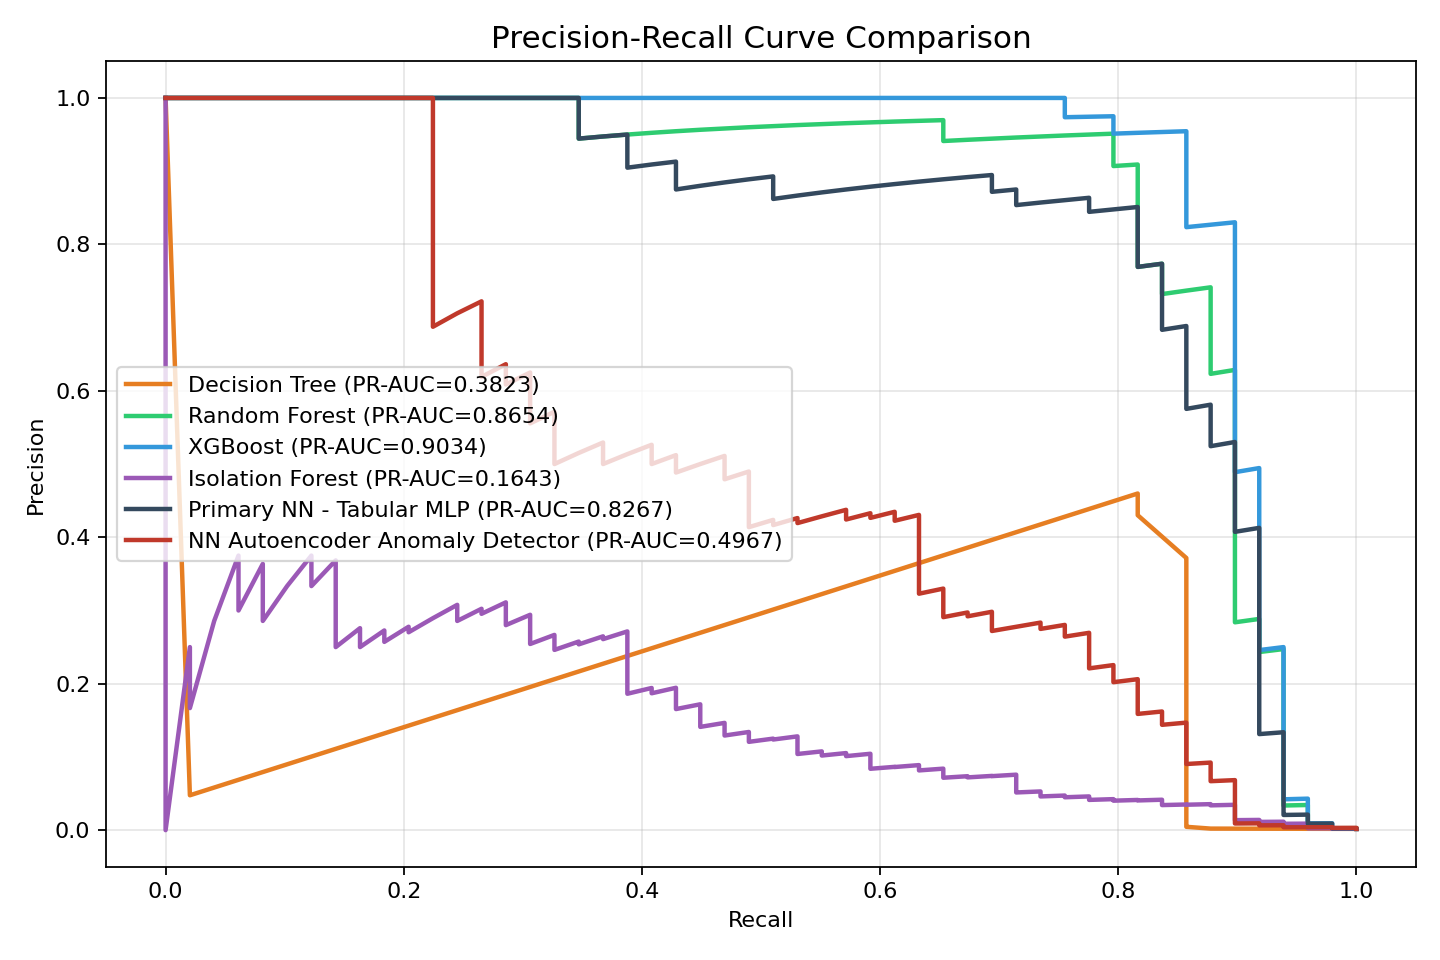

In [35]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#e67e22", "#2ecc71", "#3498db", "#9b59b6", "#34495e", "#c0392b", "#16a085"]

for (name, score), color in zip(model_scores.items(), colors):
    prec_curve, rec_curve, _ = precision_recall_curve(y_test_np, score)
    pr_auc = average_precision_score(y_test_np, score)
    ax.plot(rec_curve, prec_curve, color=color, lw=2, label=f"{name} (PR-AUC={pr_auc:.4f})")

ax.set_title("Precision-Recall Curve Comparison", fontsize=14)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "precision_recall_curves.png")


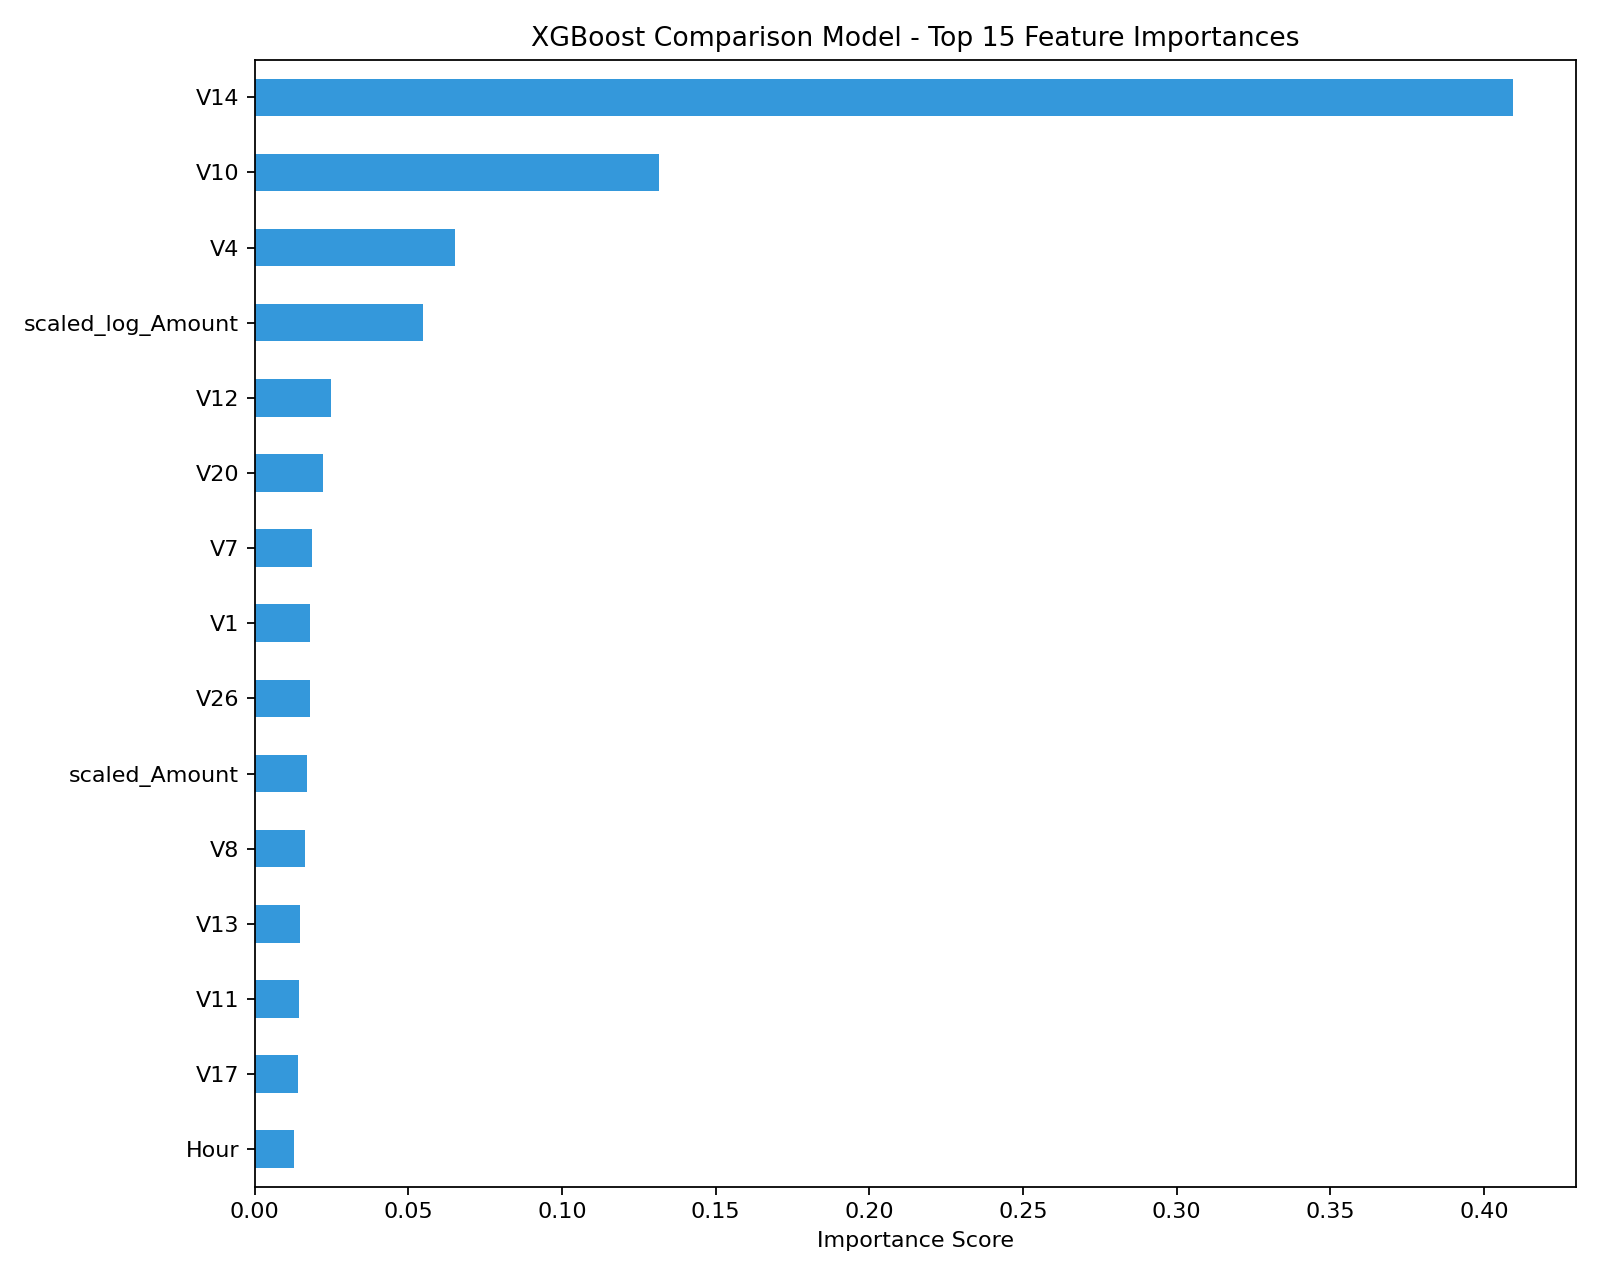

In [36]:
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
xgb_importance.tail(15).plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("XGBoost Comparison Model - Top 15 Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "xgboost_feature_importance.png")


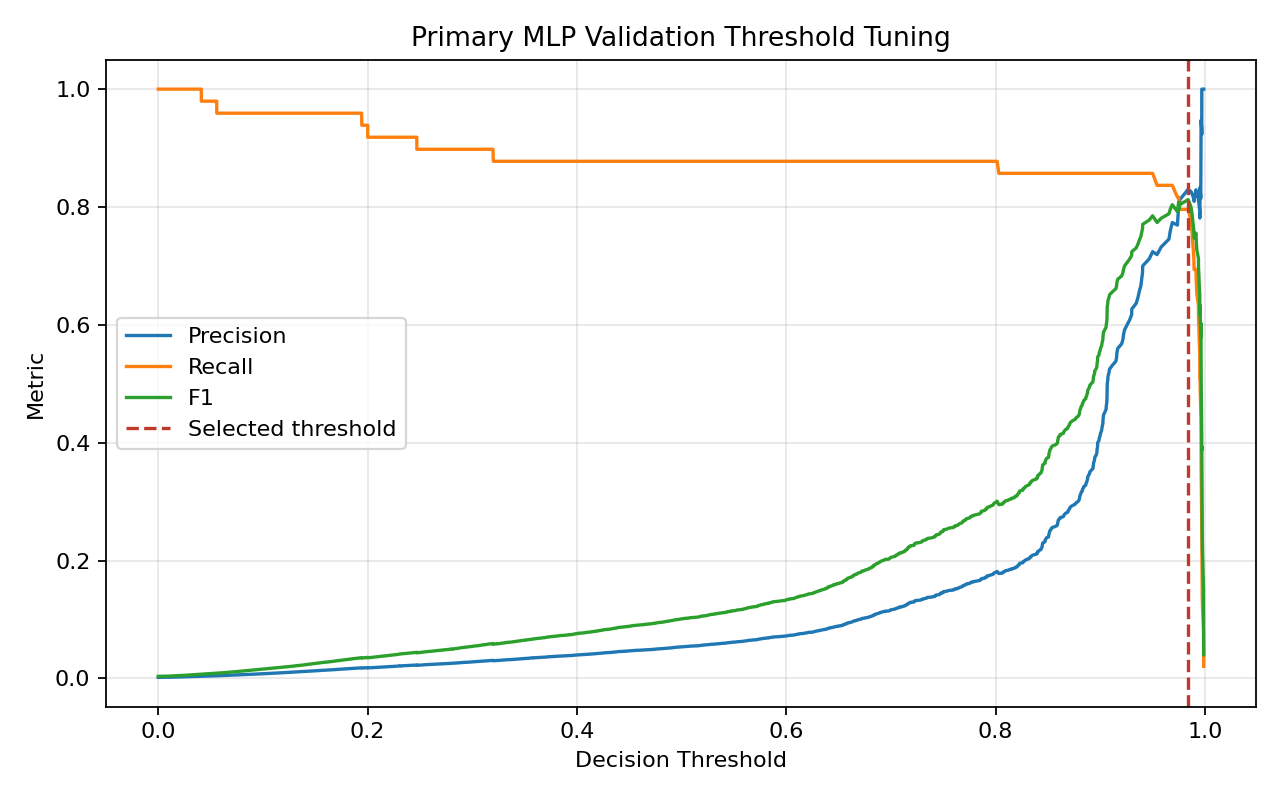

In [37]:
precision, recall, thresholds = precision_recall_curve(y_val_np.astype(int), mlp_val_prob)
f1_values = (2 * precision * recall) / np.clip(precision + recall, 1e-12, None)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision[:-1], label="Precision")
ax.plot(thresholds, recall[:-1], label="Recall")
ax.plot(thresholds, f1_values[:-1], label="F1")
ax.axvline(model_thresholds["Primary NN - Tabular MLP"], color="#c0392b", linestyle="--", label="Selected threshold")
ax.set_title("Primary MLP Validation Threshold Tuning")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Metric")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "primary_mlp_threshold_tuning.png")


---

## 5. Explainability, Slice Checks, and Security Tests


,Feature,Base PR-AUC,Shuffled PR-AUC,Importance Drop
13,V14,0.923354,0.810992,0.112362
3,V4,0.923354,0.874635,0.048719
11,V12,0.923354,0.897016,0.026338
7,V8,0.923354,0.899235,0.024119
9,V10,0.923354,0.904487,0.018867
21,V22,0.923354,0.910442,0.012912
32,scaled_Amount,0.923354,0.914911,0.008443
15,V16,0.923354,0.915996,0.007358
2,V3,0.923354,0.916127,0.007227
1,V2,0.923354,0.918211,0.005143


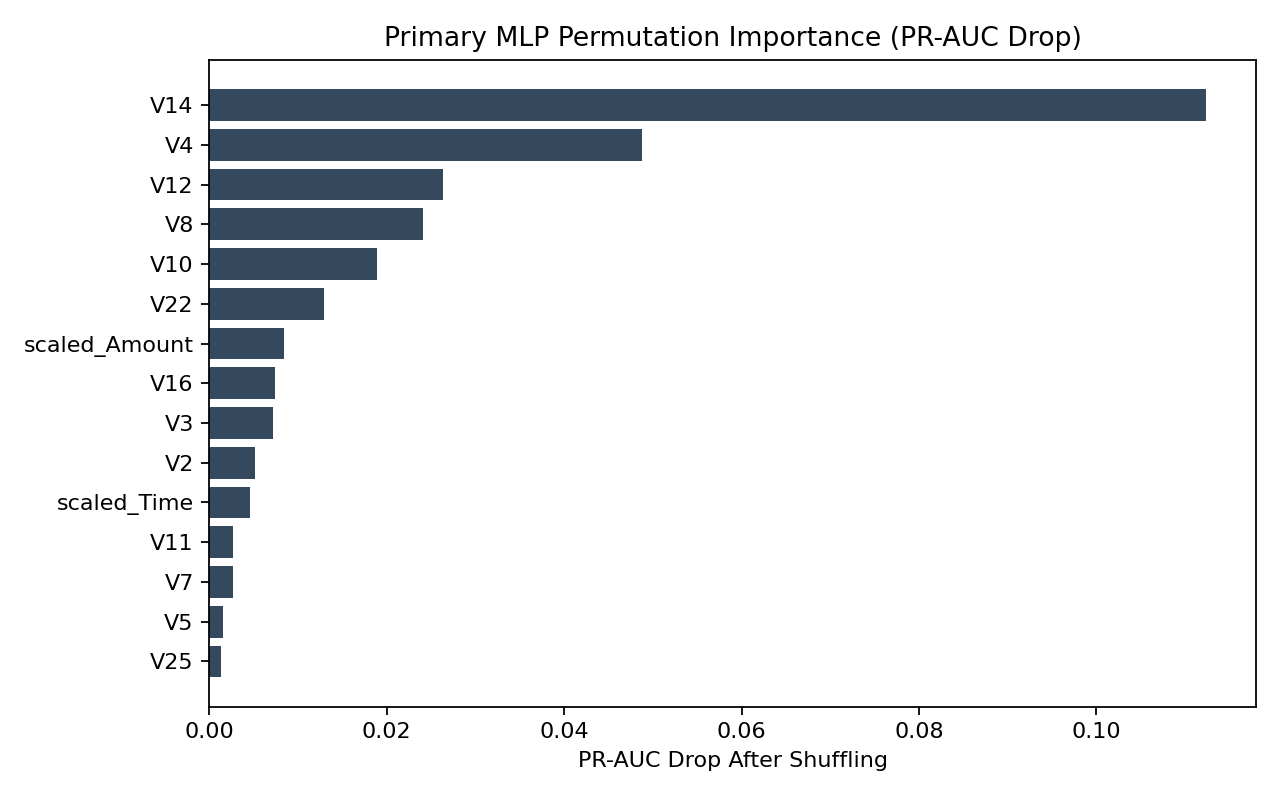

In [38]:
rng = np.random.default_rng(SEED)
subset_size = min(5000, len(X_test_np))
fraud_idx_all = np.where(y_test_np == 1)[0]
normal_idx_all = np.where(y_test_np == 0)[0]
normal_needed = max(0, subset_size - len(fraud_idx_all))
normal_sample = rng.choice(normal_idx_all, size=min(normal_needed, len(normal_idx_all)), replace=False)
subset_idx = np.concatenate([fraud_idx_all, normal_sample]) if len(fraud_idx_all) else normal_sample
rng.shuffle(subset_idx)

X_perm = X_test_np[subset_idx].copy()
y_perm = y_test_np[subset_idx].copy()
base_score = average_precision_score(y_perm, predict_proba_torch(mlp_model, X_perm))

importance_rows = []
for col_idx, feature in enumerate(feature_columns):
    shuffled = X_perm.copy()
    rng.shuffle(shuffled[:, col_idx])
    shuffled_score = average_precision_score(y_perm, predict_proba_torch(mlp_model, shuffled))
    importance_rows.append({
        "Feature": feature,
        "Base PR-AUC": float(base_score),
        "Shuffled PR-AUC": float(shuffled_score),
        "Importance Drop": float(base_score - shuffled_score),
    })

importance_df = pd.DataFrame(importance_rows).sort_values("Importance Drop", ascending=False)
importance_df.to_csv(ARTIFACT_DIR / "permutation_importance.csv", index=False)
display(importance_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_imp = importance_df.head(15).iloc[::-1]
ax.barh(top_imp["Feature"], top_imp["Importance Drop"], color="#34495e")
ax.set_title("Primary MLP Permutation Importance (PR-AUC Drop)")
ax.set_xlabel("PR-AUC Drop After Shuffling")
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "permutation_importance.png")


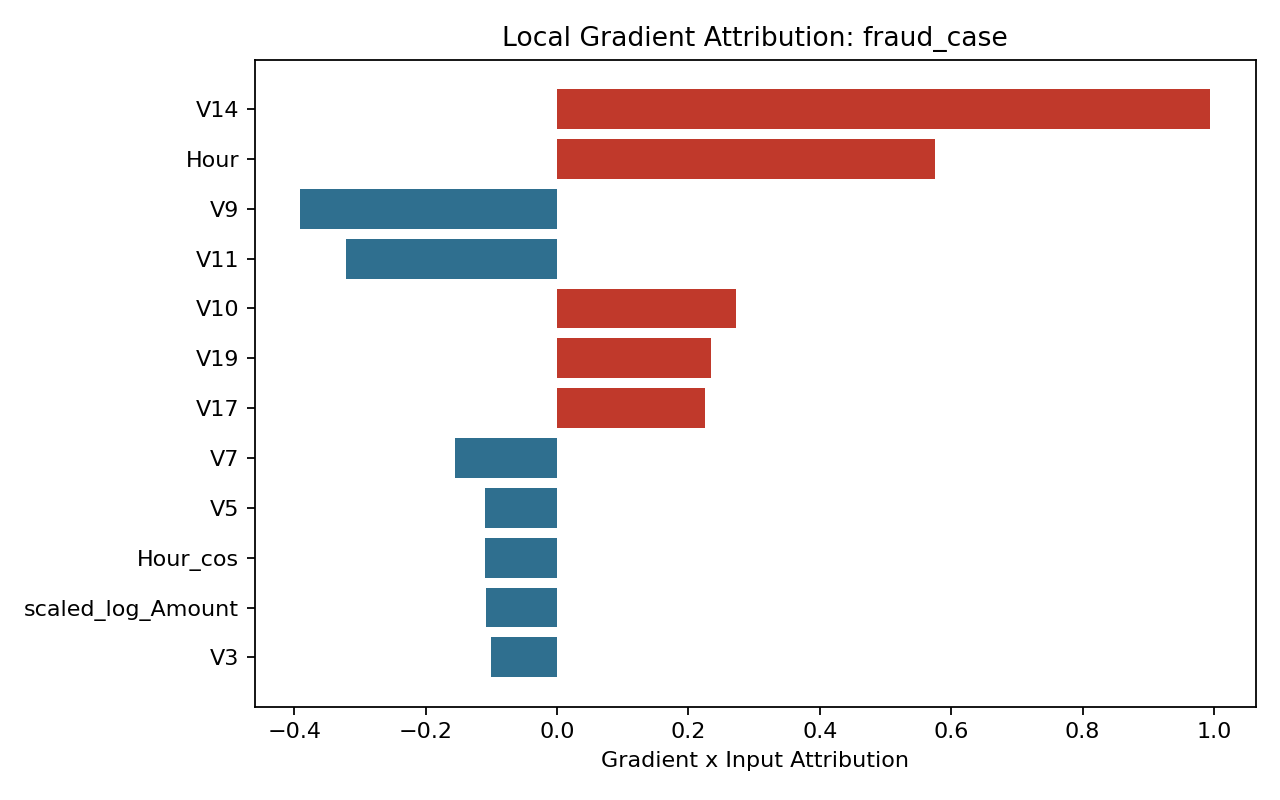

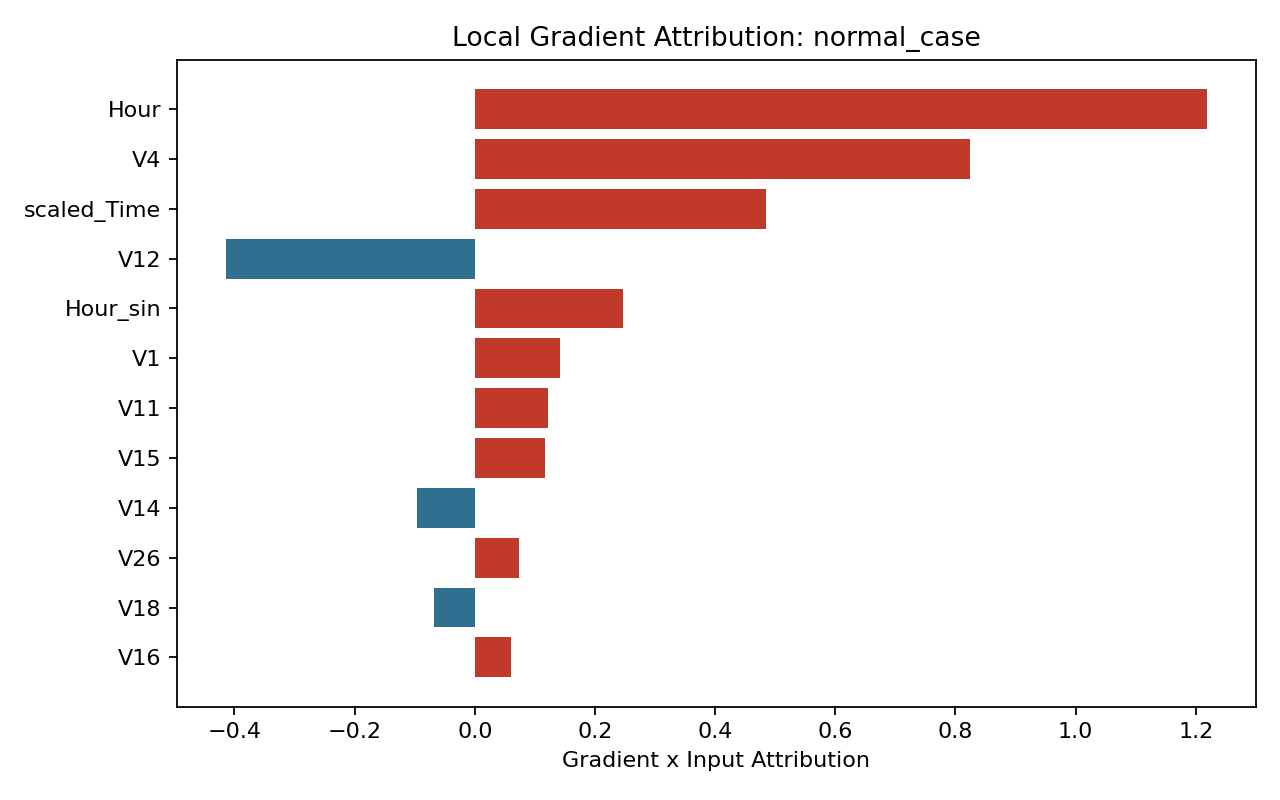

In [39]:
def local_gradient_attribution(model, sample_np):
    model.eval()
    x = torch.tensor(sample_np.reshape(1, -1), dtype=torch.float32, device=DEVICE, requires_grad=True)
    logit = model(x)
    logit.backward()
    attr = x.grad.detach().cpu().numpy()[0] * sample_np
    return attr

primary_score = model_scores["Primary NN - Tabular MLP"]
primary_threshold = model_thresholds["Primary NN - Tabular MLP"]
primary_pred = (primary_score >= primary_threshold).astype(int)
fraud_candidates = np.where((y_test_np == 1) & (primary_pred == 1))[0]
normal_candidates = np.where((y_test_np == 0) & (primary_pred == 0))[0]
fraud_explain_idx = int(fraud_candidates[0]) if len(fraud_candidates) else int(np.argmax(primary_score))
normal_explain_idx = int(normal_candidates[0]) if len(normal_candidates) else int(np.argmin(primary_score))

local_rows = []
for label, idx in [("fraud_case", fraud_explain_idx), ("normal_case", normal_explain_idx)]:
    attr = local_gradient_attribution(mlp_model, X_test_np[idx])
    local_df = pd.DataFrame({"Feature": feature_columns, "Attribution": attr})
    local_df["Abs Attribution"] = local_df["Attribution"].abs()
    local_df = local_df.sort_values("Abs Attribution", ascending=False)
    local_df.insert(0, "Case", label)
    local_df.insert(1, "Test Index Position", idx)
    local_rows.append(local_df)

    fig, ax = plt.subplots(figsize=(8, 5))
    top_local = local_df.head(12).iloc[::-1]
    colors = ["#c0392b" if v > 0 else "#2f6f8f" for v in top_local["Attribution"]]
    ax.barh(top_local["Feature"], top_local["Attribution"], color=colors)
    ax.set_title(f"Local Gradient Attribution: {label}")
    ax.set_xlabel("Gradient x Input Attribution")
    plt.tight_layout()
    save_and_show(fig, FIGURE_DIR / f"local_attribution_{label}.png")

local_attr_df = pd.concat(local_rows, ignore_index=True)
local_attr_df.to_csv(ARTIFACT_DIR / "local_gradient_attribution.csv", index=False)


,Slice Type,Slice,Total,Normal Count,Fraud Count,Flag Rate,False Positive Rate,Fraud Recall
0,Amount_Bin,Low,7126,7100,26,0.003228,0.000423,0.769231
1,Amount_Bin,Medium-Low,7115,7112,3,0.000422,0.000000,1.000000
2,Amount_Bin,Medium-High,7136,7132,4,0.000561,0.000140,0.750000
3,Amount_Bin,High,7104,7088,16,0.002252,0.000423,0.812500
4,Time_Bin,Night,2457,2446,11,0.004477,0.001226,0.727273
5,Time_Bin,Morning,6994,6980,14,0.002288,0.000573,0.857143
6,Time_Bin,Afternoon,9677,9664,13,0.001137,0.000000,0.846154
7,Time_Bin,Evening,9353,9342,11,0.000855,0.000000,0.727273


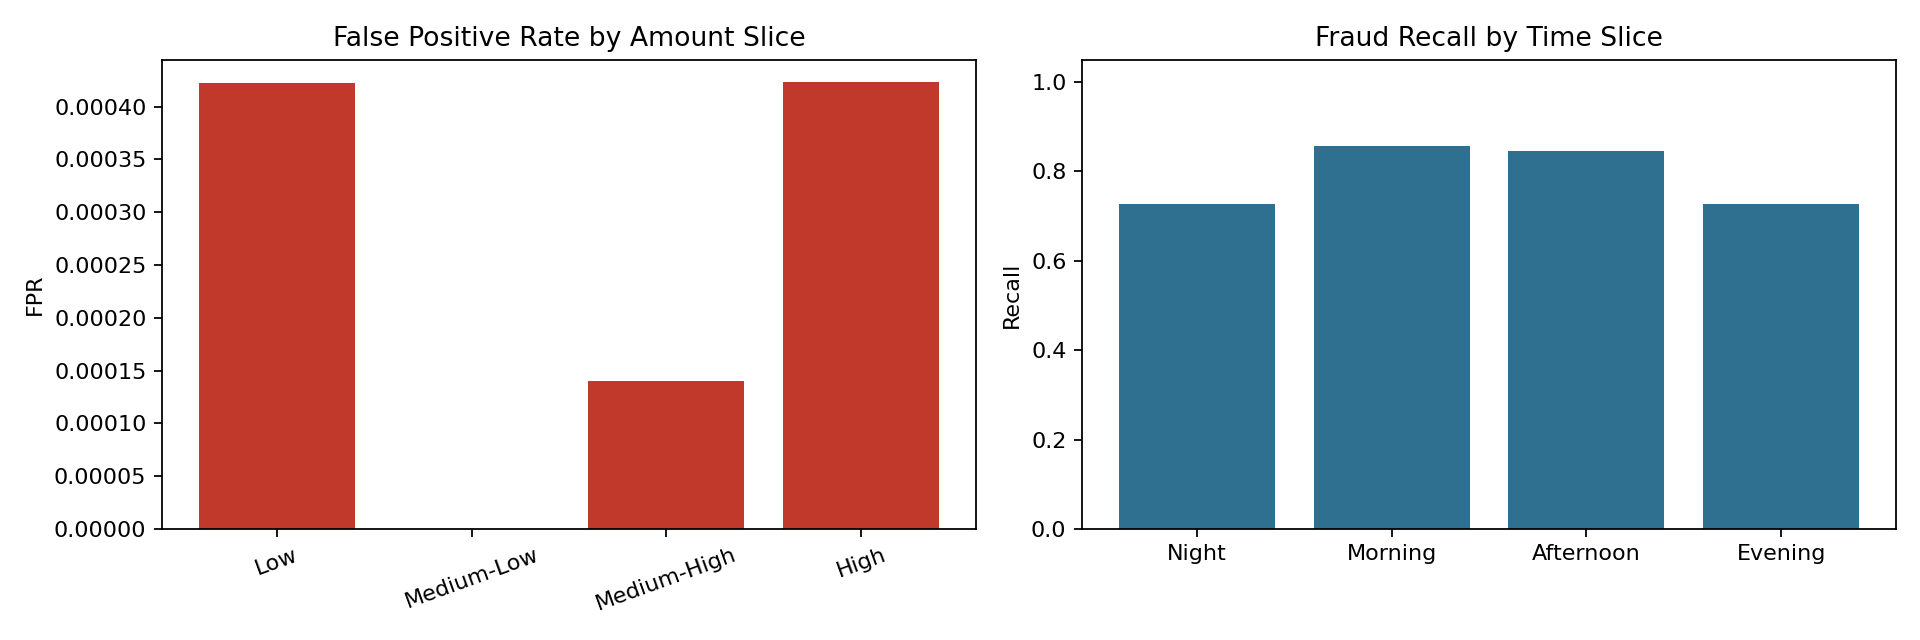

In [40]:
audit_df = pd.DataFrame({
    "Amount": X_test_raw["Amount"].to_numpy(),
    "Time": X_test_raw["Time"].to_numpy(),
    "Hour": (X_test_raw["Time"].to_numpy() % 86400) / 3600.0,
    "True_Label": y_test_np,
    "Score": primary_score,
    "Predicted": primary_pred,
})

audit_df["Amount_Bin"] = pd.qcut(audit_df["Amount"], q=4, labels=["Low", "Medium-Low", "Medium-High", "High"])
audit_df["Time_Bin"] = pd.cut(audit_df["Hour"], bins=[0, 6, 12, 18, 24],
                              labels=["Night", "Morning", "Afternoon", "Evening"],
                              include_lowest=True)

def slice_metrics(frame, group_col):
    rows = []
    for group, subset in frame.groupby(group_col, observed=False):
        normal = subset[subset["True_Label"] == 0]
        fraud = subset[subset["True_Label"] == 1]
        fp = int((normal["Predicted"] == 1).sum())
        tp = int((fraud["Predicted"] == 1).sum())
        rows.append({
            "Slice Type": group_col,
            "Slice": str(group),
            "Total": int(len(subset)),
            "Normal Count": int(len(normal)),
            "Fraud Count": int(len(fraud)),
            "Flag Rate": float(subset["Predicted"].mean()) if len(subset) else 0.0,
            "False Positive Rate": float(fp / len(normal)) if len(normal) else 0.0,
            "Fraud Recall": float(tp / len(fraud)) if len(fraud) else np.nan,
        })
    return rows

slice_df = pd.DataFrame(slice_metrics(audit_df, "Amount_Bin") + slice_metrics(audit_df, "Time_Bin"))
slice_df.to_csv(ARTIFACT_DIR / "slice_metrics.csv", index=False)
display(slice_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
amount_slice = slice_df[slice_df["Slice Type"] == "Amount_Bin"]
time_slice = slice_df[slice_df["Slice Type"] == "Time_Bin"]
axes[0].bar(amount_slice["Slice"], amount_slice["False Positive Rate"], color="#c0392b")
axes[0].set_title("False Positive Rate by Amount Slice")
axes[0].set_ylabel("FPR")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(time_slice["Slice"], time_slice["Fraud Recall"].fillna(0), color="#2f6f8f")
axes[1].set_title("Fraud Recall by Time Slice")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "slice_checks.png")


,Model,Precision,Recall,F1-Score,PR-AUC,FP,FN,TP,Notes
0,Original primary MLP test set,0.847826,0.795918,0.821053,0.826704,7,10,39,Original final test set.
1,PCA noise robustness std=0.03,0.847826,0.795918,0.821053,0.826546,7,10,39,Adds Gaussian noise to PCA features.
2,PCA noise robustness std=0.08,0.847826,0.795918,0.821053,0.823924,7,10,39,Adds Gaussian noise to PCA features.
3,Fraud amount mimicry stress test,0.844444,0.775510,0.808511,0.811601,7,11,38,"For true fraud cases only, amount-derived feat..."
4,Training-serving skew: amount features zeroed,0.847826,0.795918,0.821053,0.831173,7,10,39,Simulates an inference pipeline bug where amou...


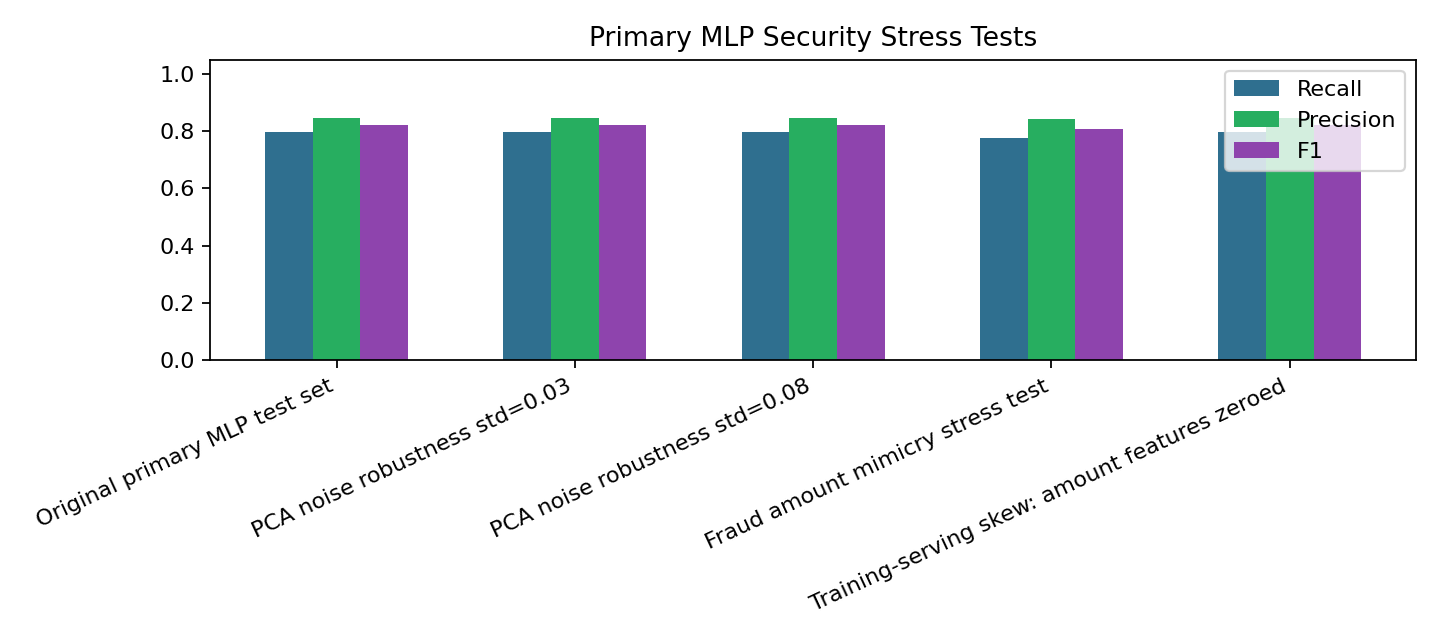

In [41]:
security_rows = []

def add_security_result(test_name, X_variant, notes):
    score = predict_proba_torch(mlp_model, X_variant.astype(np.float32))
    result = evaluate_scores(test_name, y_test_np, score, primary_threshold)
    result["Notes"] = notes
    security_rows.append(result)

add_security_result("Original primary MLP test set", X_test_np.copy(), "Original final test set.")

for noise_std in [0.03, 0.08]:
    noisy = X_test_np.copy()
    pca_cols = [feature_columns.index(f"V{i}") for i in range(1, 29)]
    noisy[:, pca_cols] += np.random.default_rng(SEED + int(noise_std * 1000)).normal(
        loc=0.0, scale=noise_std, size=noisy[:, pca_cols].shape
    ).astype(np.float32)
    add_security_result(f"PCA noise robustness std={noise_std}", noisy,
                        "Adds Gaussian noise to PCA features.")

amount_mimic = X_test_np.copy()
fraud_mask = y_test_np == 1
scaled_amount_idx = feature_columns.index("scaled_Amount")
scaled_log_amount_idx = feature_columns.index("scaled_log_Amount")
amount_mimic[fraud_mask, scaled_amount_idx] = np.quantile(X_train_np[:, scaled_amount_idx], 0.10)
amount_mimic[fraud_mask, scaled_log_amount_idx] = np.quantile(X_train_np[:, scaled_log_amount_idx], 0.10)
add_security_result("Fraud amount mimicry stress test", amount_mimic,
                    "For true fraud cases only, amount-derived features are shifted toward low-amount behavior.")

serving_skew = X_test_np.copy()
serving_skew[:, scaled_amount_idx] = 0.0
serving_skew[:, scaled_log_amount_idx] = 0.0
add_security_result("Training-serving skew: amount features zeroed", serving_skew,
                    "Simulates an inference pipeline bug where amount-derived normalized features are unavailable.")

security_df = pd.DataFrame(security_rows)
security_df.to_csv(ARTIFACT_DIR / "security_tests.csv", index=False)
display(security_df[["Model", "Precision", "Recall", "F1-Score", "PR-AUC", "FP", "FN", "TP", "Notes"]])

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(security_df))
ax.bar(x - 0.2, security_df["Recall"], width=0.2, label="Recall", color="#2f6f8f")
ax.bar(x, security_df["Precision"], width=0.2, label="Precision", color="#27ae60")
ax.bar(x + 0.2, security_df["F1-Score"], width=0.2, label="F1", color="#8e44ad")
ax.set_xticks(x)
ax.set_xticklabels(security_df["Model"], rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Primary MLP Security Stress Tests")
ax.legend()
plt.tight_layout()
save_and_show(fig, FIGURE_DIR / "security_stress_tests.png")


---

## 6. MLSecOps Metadata and Artifact Manifest


In [42]:
def gate_decision(primary, security_frame, slice_frame):
    reasons = []
    decision = "improve"
    if primary["Recall"] < 0.75:
        reasons.append("Fraud recall is below the classroom gate of 0.75.")
    if primary["Precision"] < 0.20:
        reasons.append("Precision is low enough to create likely manual-review burden.")
    if security_frame["Recall"].min() < max(0.0, primary["Recall"] - 0.20):
        reasons.append("At least one stress test drops recall by more than 0.20.")
    if slice_frame["False Positive Rate"].max() > 0.05:
        reasons.append("At least one slice has false-positive rate above 5%.")
    if not reasons:
        decision = "deploy with human review"
        reasons.append("Classroom gate passed; production use would still require live monitoring and approval.")
    return decision, reasons

approval_decision, approval_reasons = gate_decision(primary_metrics, security_df, slice_df)

split_strategy = "stratified random train/validation/test split"
permutation_fraud_rate = float(np.mean(y_perm)) if "y_perm" in globals() and len(y_perm) else float("nan")
permutation_base_pr_auc = float(base_score) if "base_score" in globals() else float("nan")


def artifact_set_identifier(*parts):
    joined = "|".join(str(part) for part in parts)
    return "sha256:" + hashlib.sha256(joined.encode("utf-8")).hexdigest()


data_quality = {
    "dataset_path": str(DATA_PATH),
    "dataset_sha256": dataset_sha256,
    "shape": list(df.shape),
    "missing_values_total": int(df.isna().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "class_counts": {str(k): int(v) for k, v in class_counts.items()},
    "fraud_rate": float(df["Class"].mean()),
    "checksum_status": "computed and enforced before loading the dataset",
}

split_summary = {
    "split_strategy": split_strategy,
    "temporal_validation_performed": False,
    "train_samples": int(len(X_train)),
    "validation_samples": int(len(X_val)),
    "test_samples": int(len(X_test)),
    "train_fraud": int(y_train.sum()),
    "validation_fraud": int(y_val.sum()),
    "test_fraud": int(y_test.sum()),
    "feature_count": len(feature_columns),
    "feature_columns": feature_columns,
}

torch.save({
    "model_state_dict": mlp_model.state_dict(),
    "feature_columns": feature_columns,
    "threshold": float(primary_threshold),
    "architecture": "FraudMLP(96-48-16)",
}, MODEL_DIR / "primary_mlp.pt")
torch.save({
    "model_state_dict": ae_model.state_dict(),
    "feature_columns": feature_columns,
    "threshold": float(model_thresholds["NN Autoencoder Anomaly Detector"]),
    "architecture": "Autoencoder(48-16-8-16-48)",
}, MODEL_DIR / "autoencoder.pt")
joblib.dump({"Decision Tree": dt_model, "Random Forest": rf_model, "XGBoost": xgb_model, "Isolation Forest": iso_model},
            MODEL_DIR / "comparison_models.joblib")

artifact_hashes = {
    "primary_mlp.pt": sha256_file(MODEL_DIR / "primary_mlp.pt"),
    "preprocessing.joblib": sha256_file(MODEL_DIR / "preprocessing.joblib"),
    "autoencoder.pt": sha256_file(MODEL_DIR / "autoencoder.pt"),
    "comparison_models.joblib": sha256_file(MODEL_DIR / "comparison_models.joblib"),
}
artifact_set_id = artifact_set_identifier(dataset_sha256, artifact_hashes["primary_mlp.pt"], artifact_hashes["preprocessing.joblib"])
run_timestamp_utc = datetime.now(timezone.utc).isoformat()

run_metadata = {
    "run_id": artifact_set_id,
    "artifact_set_id": artifact_set_id,
    "run_timestamp_utc": run_timestamp_utc,
    "project": "AISec Final - SDG 8 Credit Card Fraud Detection",
    "dataset": data_quality,
    "split_summary": split_summary,
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch": torch.__version__,
        "device": str(DEVICE),
    },
    "primary_model": {
        "name": "Primary NN - Tabular MLP",
        "architecture": "FraudMLP(96-48-16)",
        "threshold": float(primary_threshold),
        "threshold_selection": "max validation F1; not a review-capacity or business-cost optimization",
        "artifact_path": "artifacts/models/primary_mlp.pt",
        "artifact_sha256": artifact_hashes["primary_mlp.pt"],
        "metrics": to_builtin(primary_metrics),
    },
    "preprocessing": {
        "artifact_path": "artifacts/models/preprocessing.joblib",
        "artifact_sha256": artifact_hashes["preprocessing.joblib"],
        "feature_columns": feature_columns,
    },
    "evaluation_limits": {
        "temporal_validation_performed": False,
        "temporal_validation_note": "The dataset covers a two-day sequence, but this classroom run uses a stratified random split rather than a future-time holdout.",
        "permutation_importance_subset": {
            "rows": int(len(y_perm)) if "y_perm" in globals() else None,
            "fraud_cases": int(np.sum(y_perm)) if "y_perm" in globals() else None,
            "fraud_rate": permutation_fraud_rate,
            "base_pr_auc": permutation_base_pr_auc,
        },
        "security_stress_scope": "Limited classroom stress tests: PCA noise, amount mimicry, and amount-feature serving skew; not complete coverage of the threat model.",
    },
    "approval_gate": {
        "decision": approval_decision,
        "reasons": approval_reasons,
    },
}

(ARTIFACT_DIR / "data_quality.json").write_text(json.dumps(to_builtin(data_quality), indent=2), encoding="utf-8")
(ARTIFACT_DIR / "split_summary.json").write_text(json.dumps(to_builtin(split_summary), indent=2), encoding="utf-8")
(ARTIFACT_DIR / "run_metadata.json").write_text(json.dumps(to_builtin(run_metadata), indent=2), encoding="utf-8")


def fmt_number(value, digits=4):
    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.{digits}f}"
    return str(value)


def md_table(frame, columns):
    columns = [col for col in columns if col in frame.columns]
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = []
    for _, row in frame[columns].iterrows():
        rows.append("| " + " | ".join(fmt_number(row[col]) for col in columns) + " |")
    return "\n".join([header, divider] + rows)

metric_columns = ["Model", "Threshold", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC", "FP", "FN", "TP"]
security_columns = ["Model", "Precision", "Recall", "F1-Score", "PR-AUC", "FP", "FN", "TP", "Notes"]
slice_columns = ["Slice Type", "Slice", "Total", "Fraud Count", "Flag Rate", "False Positive Rate", "Fraud Recall"]
feature_list = ", ".join(feature_columns)


data_card_md = f'''# Data Card: Credit Card Fraud Detection Dataset

## Dataset Identity

- Dataset file used by this project: `creditcard.csv`
- Source identity: public credit card fraud detection dataset from the ULB Machine Learning Group / Worldline research collaboration.
- Source URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data
- License: Database: Open Database; Contents: Database Contents
- Original context: European cardholder transactions from September 2013 over a two-day period.
- Project task: binary fraud detection for SDG 8 financial security and trustworthy economic activity.
- Target label: `Class`, where `1` means fraudulent transaction and `0` means normal transaction.
- Checksum from this run: `{dataset_sha256}`

## Dataset Summary

- Records: {len(df):,}
- Columns: {df.shape[1]:,}
- Normal transactions: {int(class_counts.get(0, 0)):,}
- Fraud transactions: {int(class_counts.get(1, 0)):,}
- Fraud rate: {df["Class"].mean() * 100:.4f}%
- Missing values: {int(df.isna().sum().sum()):,}
- Duplicate rows detected: {int(df.duplicated().sum()):,}

## Schema and Features

- Original columns: `Time`, `Amount`, anonymized PCA features `V1` to `V28`, and `Class`.
- Engineered features: `Hour`, `Hour_sin`, `Hour_cos`, `scaled_Time`, `scaled_Amount`, and `scaled_log_Amount`.
- Final feature count: {len(feature_columns)}
- Final feature list: {feature_list}

## Processing Lineage

- The notebook loads one local CSV file named `creditcard.csv`.
- The split strategy is `{split_strategy}`.
- Temporal validation is not performed in this classroom run; future-time performance may differ from this random holdout estimate.
- Training samples: {len(X_train):,}; fraud: {int(y_train.sum()):,}
- Validation samples: {len(X_val):,}; fraud: {int(y_val.sum()):,}
- Test samples: {len(X_test):,}; fraud: {int(y_test.sum()):,}
- Scaling is fitted on the training split only and then applied to validation and test data.
- SMOTE is applied only to the training split for classical comparison models.
- Neural-network training uses imbalance-aware sampling without changing validation or test labels.

## Quality, Fairness, and Privacy Limits

- The dataset is extremely imbalanced, so PR-AUC, recall, precision, and error counts are more meaningful than accuracy alone.
- The dataset does not include demographic attributes. Direct demographic fairness cannot be measured.
- Amount-bin and time-window slice checks are proxy reliability checks, not demographic fairness claims.
- PCA-anonymized features reduce exposure of raw transaction attributes, but they do not guarantee complete privacy.

## Security Controls

- Dataset checksum is computed and enforced before loading the dataset. A mismatch stops the notebook before training or artifact generation.
- Data quality, split metadata, artifact manifest, and limited stress-test outputs are generated at runtime.
- Production use would still require access control, data retention controls, poisoning monitoring, and incident response.
'''

model_card_md = f'''# Model Card: Primary NN Tabular MLP Fraud Classifier

## Model Identity

- Model name: Primary NN - Tabular MLP
- Architecture: FraudMLP(96-48-16)
- Implementation: PyTorch tabular neural network
- Runtime environment: Python {platform.python_version()}, PyTorch {torch.__version__}, device `{DEVICE}`
- Model artifact: `artifacts/models/primary_mlp.pt`
- Artifact set ID: `{artifact_set_id}`
- Intended use: fraud-risk scoring for credit card transactions with human review.
- Prohibited use: fully automated punishment, account blocking, or production deployment without monitoring and governance approval.

## Training Data and Features

- Dataset checksum: `{dataset_sha256}`
- Split strategy: {split_strategy}
- Temporal validation: not performed; this is a random holdout estimate on a two-day dataset, not a future-time deployment test.
- Training samples: {len(X_train):,}
- Validation samples: {len(X_val):,}
- Test samples: {len(X_test):,}
- Feature count: {len(feature_columns)}
- Decision threshold selected on validation data: {float(primary_threshold):.6f}

## Test Metrics

{md_table(results_df, metric_columns)}

## Primary Model Decision Policy

- The model outputs a fraud probability score.
- Transactions at or above the selected threshold should be routed to human review.
- The threshold is selected by maximizing validation F1. It is not a review-capacity, business-cost, or production workload optimization.
- Approval gate decision: **{approval_decision}**.
- Approval reason: {"; ".join(approval_reasons)}

## Explainability Evidence

- Global NN explanation: `artifacts/permutation_importance.csv` and `artifacts/figures/permutation_importance.png`.
- Permutation importance uses {int(len(y_perm)) if "y_perm" in globals() else "unknown"} test rows: all available fraud cases plus sampled normal cases. Its fraud rate is {permutation_fraud_rate:.4%}, so its base PR-AUC ({permutation_base_pr_auc:.4f}) is not directly comparable to the original test-set PR-AUC under the original prevalence.
- Local NN explanation: `artifacts/local_gradient_attribution.csv` and local attribution figures.
- Top global importance features from permutation importance:

{md_table(importance_df.head(10), ["Feature", "Importance Drop"])}

## Slice and Reliability Checks

{md_table(slice_df, slice_columns)}

## Security Stress Tests

These are limited classroom stress tests for PCA noise, amount mimicry, and amount-feature serving skew. They do not fully test data poisoning, model extraction, account compromise, rate-limit abuse, or all adaptive fraud strategies in the threat model.

{md_table(security_df, security_columns)}

## Monitoring, Rollback, and Residual Risk

- Monitor input schema, amount distribution drift, fraud-rate drift, score distribution drift, review workload, and post-label precision/recall.
- Roll back or block deployment if recall drops materially, false positives exceed review capacity, or data quality checks fail.
- Residual risks include adaptive fraud behavior, missing demographic fairness attributes, PCA privacy limitations, possible training-serving skew in production, and the lack of temporal validation in this classroom run.

## Reference Deployment

- Deployment repository: [Willy19928/Credit_Card_Fraud_Detection_Server](https://github.com/Willy19928/Credit_Card_Fraud_Detection_Server)
- Required artifacts: `artifacts/models/primary_mlp.pt`, `artifacts/models/preprocessing.joblib`, and `artifacts/run_metadata.json`.
- Runtime behavior: the server recreates the notebook's feature engineering, calculates a fraud probability, and uses the checkpoint's validation-selected threshold.
- Decision routing: transactions at or above the threshold are marked for human review; the service does not automatically block accounts.
- Model replacement: update `primary_mlp.pt`, `preprocessing.joblib`, `run_metadata.json`, and `model_manifest.json` before service startup; the deployed service does not accept live model uploads.
- Deployment limitations: the reference server is a classroom deployment implementation and does not remove the monitoring, governance, authentication, rate-limiting, logging, or incident-response requirements listed above.
'''

card_files = {
    PROJECT_DIR / "DATA_CARD.md": data_card_md,
    PROJECT_DIR / "MODEL_CARD.md": model_card_md,
    ARTIFACT_DIR / "DATA_CARD.md": data_card_md,
    ARTIFACT_DIR / "MODEL_CARD.md": model_card_md,
}
for card_path, card_text in card_files.items():
    card_path.write_text(card_text, encoding="utf-8")

display(Markdown("## Generated Data Card and Model Card\n\n"
                 "- `DATA_CARD.md`\n"
                 "- `MODEL_CARD.md`\n"
                 "The files are also copied into `artifacts/` and included in the artifact package."))

print(json.dumps(run_metadata["approval_gate"], indent=2))
print("\nPrimary model metrics:")
print(json.dumps(to_builtin(primary_metrics), indent=2))


## Generated Data Card and Model Card

- `DATA_CARD.md`
- `MODEL_CARD.md`

The files are also copied into `artifacts/` and included in the artifact package.

{
  "decision": "deploy with human review",
  "reasons": [
    "Classroom gate passed; production use would still require live monitoring and approval."
  ]
}

Primary model metrics:
{
  "Model": "Primary NN - Tabular MLP",
  "Threshold": 0.9838983416557312,
  "Accuracy": 0.999403110845827,
  "Precision": 0.8478260869565217,
  "Recall": 0.7959183673469388,
  "F1-Score": 0.8210526315789474,
  "ROC-AUC": 0.9800210742710139,
  "PR-AUC": 0.8267043216826518,
  "TN": 28425,
  "FP": 7,
  "FN": 10,
  "TP": 39,
  "Training Seconds": 20.88003897666931,
  "validation_precision": 0.8297872340425532,
  "validation_recall": 0.7959183673469388,
  "validation_f1": 0.8125,
  "best_epoch": 2.0,
  "best_validation_pr_auc": 0.7700777429924166
}


In [43]:
artifact_listing = []
for path in sorted(ARTIFACT_DIR.rglob("*")):
    if path.is_file() and path.name != "artifact_manifest.csv":
        artifact_listing.append({
            "path": str(path.relative_to(PROJECT_DIR)),
            "size_bytes": path.stat().st_size,
            "sha256": sha256_artifact(path),
        })
artifact_df = pd.DataFrame(artifact_listing)
artifact_df.to_csv(ARTIFACT_DIR / "artifact_manifest.csv", index=False)
display(artifact_df)

zip_base = PROJECT_DIR / "AISec_Final_Artifacts"
zip_candidate = zip_base.with_suffix(".zip")
if zip_candidate.exists():
    zip_candidate.unlink()
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=ARTIFACT_DIR)
print(f"Artifact package: {zip_path}")


,path,size_bytes
0,artifacts\autoencoder_training_history.csv,353
1,artifacts\DATA_CARD.md,2514
2,artifacts\data_quality.json,320
3,artifacts\figures\class_distribution.png,59190
4,artifacts\figures\confusion_matrices_and_roc.png,176879
5,artifacts\figures\eda_summary.png,113280
6,artifacts\figures\local_attribution_fraud_case.png,38847
7,artifacts\figures\local_attribution_normal_case.png,38129
8,artifacts\figures\pca_feature_distributions.png,118636
9,artifacts\figures\permutation_importance.png,46887


Artifact package: /content/AISec_Final_Artifacts.zip
